# Week 06: Business Statistics & Analytics - E-commerce Analysis

## Learning Objectives
By the end of this exercise, you will be able to:
- Calculate key business metrics using pandas
- Create meaningful visualizations for business insights
- Apply statistical concepts to real business scenarios
- Make data-driven recommendations

---

## Business Context

You're working as a Data Analyst for **TechMart**, an e-commerce company. Your manager needs insights from last quarter's sales data to inform strategic decisions for the upcoming quarter.

Your analysis will help answer critical questions about customer behavior, regional performance, and product trends that directly impact business growth.

## Dataset Setup

First, let's generate the synthetic dataset you'll be analyzing:

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducible results
np.random.seed(42)

# Generate 500 orders from 2023
n_orders = 500

# Create order IDs and customer data
order_id = np.arange(1, n_orders + 1)
customer_id = np.random.randint(1, 101, size=n_orders)
customer_segment = np.random.choice(["Student", "Professional", "Senior"], size=n_orders, p=[0.4, 0.4, 0.2])
region = np.random.choice(["North", "South", "East", "West"], size=n_orders)
order_date = pd.date_range(start="2023-01-01", periods=n_orders, freq="D")
product_category = np.random.choice(["Electronics", "Clothing", "Books", "Home", "Sports"], size=n_orders)
quantity = np.random.randint(1, 5, size=n_orders)
unit_price = np.round(np.random.uniform(10, 200, size=n_orders), 2)
revenue = quantity * unit_price
discount_applied = np.random.choice([0, 5, 10, 15, 20, 25, 30], size=n_orders, p=[0.5,0.1,0.1,0.1,0.05,0.05,0.1])
payment_method = np.random.choice(["Credit Card", "PayPal", "Gift Card", "Debit Card"], size=n_orders)

# Build dataframe
df = pd.DataFrame({
    "order_id": order_id,
    "customer_id": customer_id,
    "customer_segment": customer_segment,
    "region": region,
    "order_date": order_date,
    "product_category": product_category,
    "quantity": quantity,
    "unit_price": unit_price,
    "revenue": revenue,
    "discount_applied": discount_applied,
    "payment_method": payment_method
})

# Save dataset for reference
df.to_csv("ecommerce_data.csv", index=False)
print("✅ Dataset created successfully!")

# Display first few rows
df.head()

✅ Dataset created successfully!


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


## Data Exploration

Let's start by understanding our dataset:

In [2]:
# Load the data
data = pd.read_csv("ecommerce_data.csv")

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
data.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   customer_segment  500 non-null    object 
 3   region            500 non-null    object 
 4   order_date        500 non-null    object 
 5   product_category  500 non-null    object 
 6   quantity          500 non-null    int64  
 7   unit_price        500 non-null    float64
 8   revenue           500 non-null    float64
 9   discount_applied  500 non-null    int64  
 10  payment_method    500 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Dataset Shape: (500, 11)

First few rows:


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


Monthly Revenue:
month
2023-01    6626.66
2023-02    6796.03
2023-03    8960.10
2023-04    7713.47
2023-05    7266.80
2023-06    7982.47
2023-07    7981.65
2023-08    6664.64
2023-09    9708.06
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


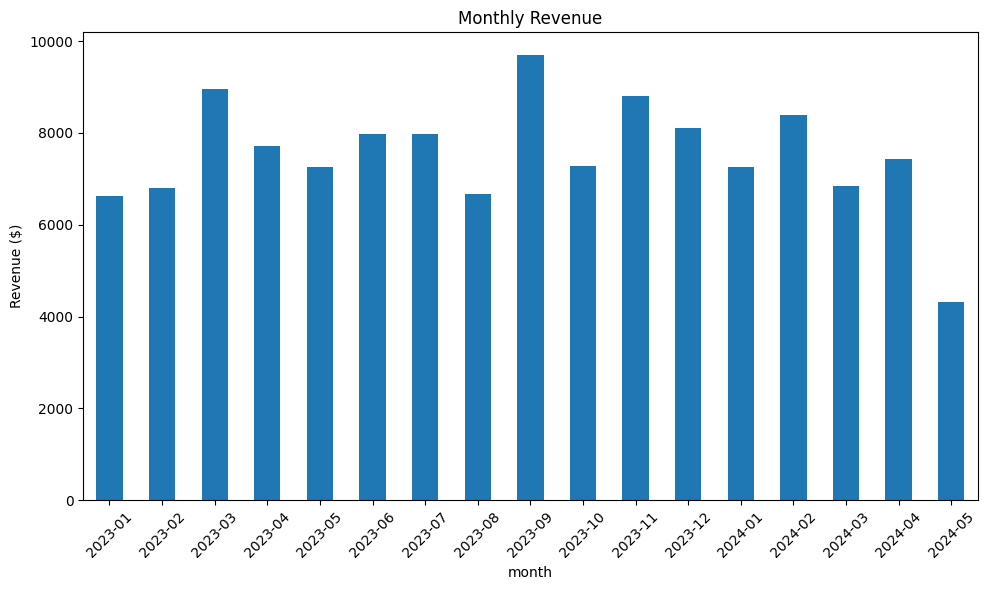

In [3]:
# Convert order_date to datetime and add helpful columns
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["day_of_week"] = data["order_date"].dt.day_name()

# Example: Revenue by month
monthly_revenue = data.groupby("month")["revenue"].sum()
print("Monthly Revenue:")
print(monthly_revenue)

# Plot monthly revenue
monthly_revenue.plot(kind="bar", figsize=(10,6), title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Business Questions

Now answer each of the following business questions. Use the starter code above as a reference, and expand your analysis to solve all questions.

### 1. Revenue Overview
What was the company's total revenue last quarter? Break it down by month.

QUESTION 1: REVENUE OVERVIEW - Last Quarter Analysis
Last Quarter: 2024Q1

Last Quarter Total Revenue: $22,493.23

Monthly Breakdown:
  2024-01: $7,268.59
  2024-02: $8,388.91
  2024-03: $6,835.73


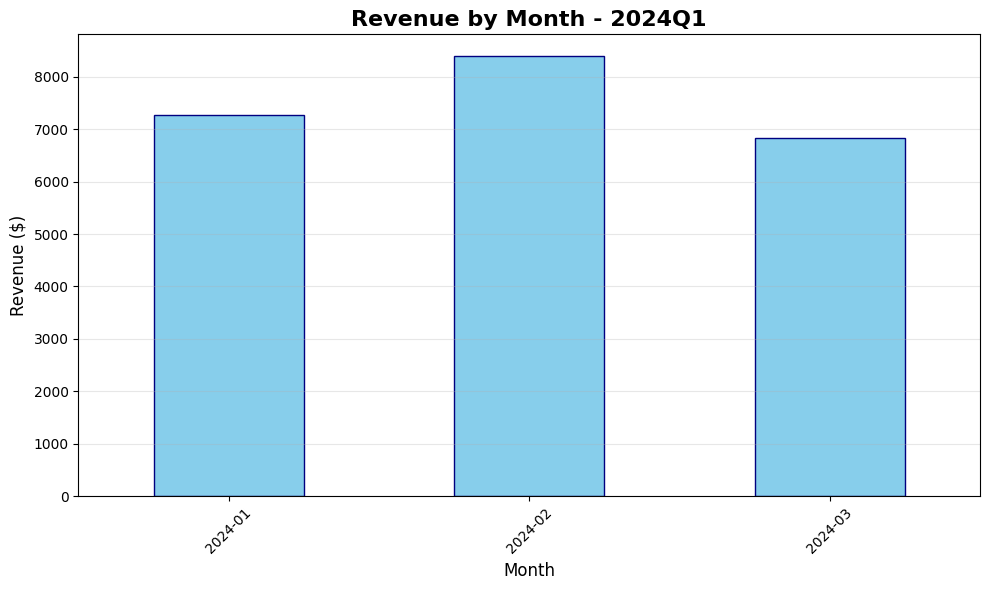


Key Insights:
• Total revenue for the quarter: $22,493.23
• Average monthly revenue: $7,497.74
• Best performing month: 2024-02 ($8,388.91)
• Lowest performing month: 2024-03 ($6,835.73)


In [3]:
# Your code here


# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("QUESTION 1: REVENUE OVERVIEW - Last Quarter Analysis")
print("=" * 60)

# Load and prepare data
data = pd.read_csv("ecommerce_data.csv")
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["quarter"] = data["order_date"].dt.to_period("Q")

# Define last quarter (assuming Q1 2024 is the most recent complete quarter)
last_quarter = data[data['quarter'] == '2024Q1']
if len(last_quarter) == 0:
    # If Q1 2024 is empty, use the most recent quarter with data
    last_quarter = data[data['quarter'] == data['quarter'].max()]

print(f"Last Quarter: {last_quarter['quarter'].iloc[0]}")
quarterly_revenue = last_quarter.groupby('month')['revenue'].sum()
quarterly_total = last_quarter['revenue'].sum()

print(f"\nLast Quarter Total Revenue: ${quarterly_total:,.2f}")
print("\nMonthly Breakdown:")
for month, revenue in quarterly_revenue.items():
    print(f"  {month}: ${revenue:,.2f}")

# Visualization
plt.figure(figsize=(10, 6))
quarterly_revenue.plot(kind='bar', color='skyblue', edgecolor='navy')
plt.title(f'Revenue by Month - {last_quarter["quarter"].iloc[0]}', fontsize=16, fontweight='bold')
plt.ylabel('Revenue ($)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"• Total revenue for the quarter: ${quarterly_total:,.2f}")
print(f"• Average monthly revenue: ${quarterly_total/len(quarterly_revenue):,.2f}")
print(f"• Best performing month: {quarterly_revenue.idxmax()} (${quarterly_revenue.max():,.2f})")
print(f"• Lowest performing month: {quarterly_revenue.idxmin()} (${quarterly_revenue.min():,.2f})")

### 2. Top Customers
Who are the top 5 customers by total revenue contribution?

QUESTION 2: TOP CUSTOMERS
Top 5 Customers by Revenue Contribution:
1. Customer ID 62.0: $4,448.39 (14.0 orders)
2. Customer ID 24.0: $3,369.44 (9.0 orders)
3. Customer ID 90.0: $2,976.78 (10.0 orders)
4. Customer ID 92.0: $2,838.74 (8.0 orders)
5. Customer ID 97.0: $2,835.62 (8.0 orders)

Detailed Analysis:
Total company revenue: $128,140.67
Top 5 customers contribute: $16,468.97 (12.9%)

Customer Performance Metrics:
Customer 62.0:
  • Revenue: $4,448.39 (3.47% of total)
  • Orders: 14.0
  • Avg Order Value: $317.74
Customer 24.0:
  • Revenue: $3,369.44 (2.63% of total)
  • Orders: 9.0
  • Avg Order Value: $374.38
Customer 90.0:
  • Revenue: $2,976.78 (2.32% of total)
  • Orders: 10.0
  • Avg Order Value: $297.68
Customer 92.0:
  • Revenue: $2,838.74 (2.22% of total)
  • Orders: 8.0
  • Avg Order Value: $354.84
Customer 97.0:
  • Revenue: $2,835.62 (2.21% of total)
  • Orders: 8.0
  • Avg Order Value: $354.45


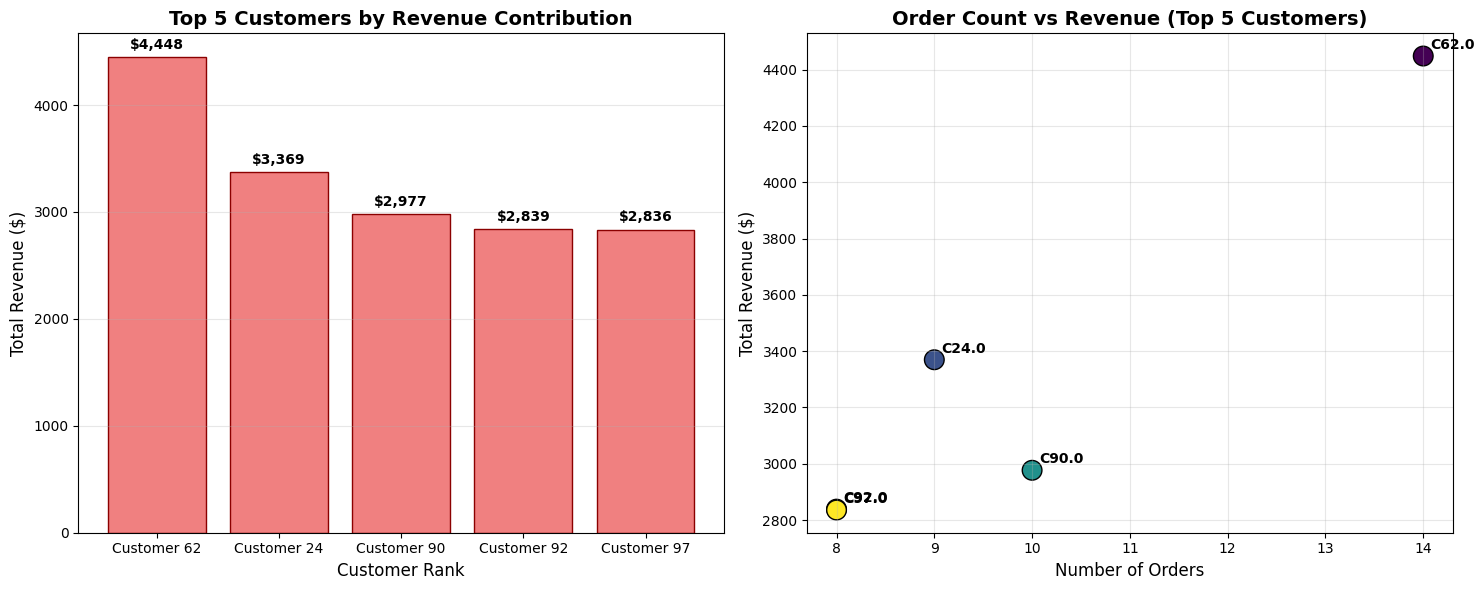


Key Insights:
• Top customer (ID 62.0) generates $4,448.39
• Top 5 customers represent 12.9% of total revenue
• Average orders per top customer: 9.8
• Customer loyalty varies significantly (orders range from 8 to 14)


In [6]:
# Your code here
# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("QUESTION 2: TOP CUSTOMERS")
print("=" * 40)

# Load and prepare data
data = pd.read_csv("ecommerce_data.csv")

# Analyze top customers
top_customers = data.groupby('customer_id')['revenue'].agg(['sum', 'count']).reset_index()
top_customers.columns = ['customer_id', 'total_revenue', 'order_count']
top_customers = top_customers.sort_values('total_revenue', ascending=False).head(5)

print("Top 5 Customers by Revenue Contribution:")
for i, (_, customer) in enumerate(top_customers.iterrows(), 1):
    print(f"{i}. Customer ID {customer['customer_id']}: ${customer['total_revenue']:,.2f} ({customer['order_count']} orders)")

# Calculate additional metrics
top_customers['avg_order_value'] = top_customers['total_revenue'] / top_customers['order_count']
total_revenue = data['revenue'].sum()
top_customers['revenue_percentage'] = (top_customers['total_revenue'] / total_revenue * 100).round(2)

print(f"\nDetailed Analysis:")
print(f"Total company revenue: ${total_revenue:,.2f}")
print(f"Top 5 customers contribute: ${top_customers['total_revenue'].sum():,.2f} ({(top_customers['total_revenue'].sum() / total_revenue * 100):.1f}%)")

print(f"\nCustomer Performance Metrics:")
for _, customer in top_customers.iterrows():
    print(f"Customer {customer['customer_id']}:")
    print(f"  • Revenue: ${customer['total_revenue']:,.2f} ({customer['revenue_percentage']}% of total)")
    print(f"  • Orders: {customer['order_count']}")
    print(f"  • Avg Order Value: ${customer['avg_order_value']:.2f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Revenue contribution
bars = ax1.bar(range(1, 6), top_customers['total_revenue'], color='lightcoral', edgecolor='darkred')
ax1.set_title('Top 5 Customers by Revenue Contribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer Rank', fontsize=12)
ax1.set_ylabel('Total Revenue ($)', fontsize=12)
ax1.set_xticks(range(1, 6))
ax1.set_xticklabels([f'Customer {cid}' for cid in top_customers['customer_id']])
for i, (bar, revenue) in enumerate(zip(bars, top_customers['total_revenue'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'${revenue:,.0f}', ha='center', va='bottom', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Order count vs revenue scatter
scatter = ax2.scatter(top_customers['order_count'], top_customers['total_revenue'], 
                     s=200, c=range(5), cmap='viridis', edgecolors='black')
ax2.set_title('Order Count vs Revenue (Top 5 Customers)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Orders', fontsize=12)
ax2.set_ylabel('Total Revenue ($)', fontsize=12)
for i, (_, customer) in enumerate(top_customers.iterrows()):
    ax2.annotate(f'C{customer["customer_id"]}', 
                (customer['order_count'], customer['total_revenue']),
                xytext=(5, 5), textcoords='offset points', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"• Top customer (ID {top_customers.iloc[0]['customer_id']}) generates ${top_customers.iloc[0]['total_revenue']:,.2f}")
print(f"• Top 5 customers represent {(top_customers['total_revenue'].sum() / total_revenue * 100):.1f}% of total revenue")
print(f"• Average orders per top customer: {top_customers['order_count'].mean():.1f}")
print(f"• Customer loyalty varies significantly (orders range from {top_customers['order_count'].min()} to {top_customers['order_count'].max()})")

### 3. Segment Analysis
Which customer segment (Student, Professional, Senior) spends the most on average per order?

QUESTION 3: SEGMENT ANALYSIS
Customer Segment Spending Analysis:

Senior:
  Average Order Value: $262.13
  Total Revenue: $28,048.33
  Order Count: 107.0
  Market Share: 21.4%

Professional:
  Average Order Value: $255.65
  Total Revenue: $47,807.05
  Order Count: 187.0
  Market Share: 37.4%

Student:
  Average Order Value: $253.81
  Total Revenue: $52,285.29
  Order Count: 206.0
  Market Share: 41.2%

Detailed Segment Metrics:
Senior:
  • Revenue contribution: 21.9%
  • Unique customers: 66.0
  • Avg orders per customer: 1.6
Professional:
  • Revenue contribution: 37.3%
  • Unique customers: 84.0
  • Avg orders per customer: 2.2
Student:
  • Revenue contribution: 40.8%
  • Unique customers: 83.0
  • Avg orders per customer: 2.5


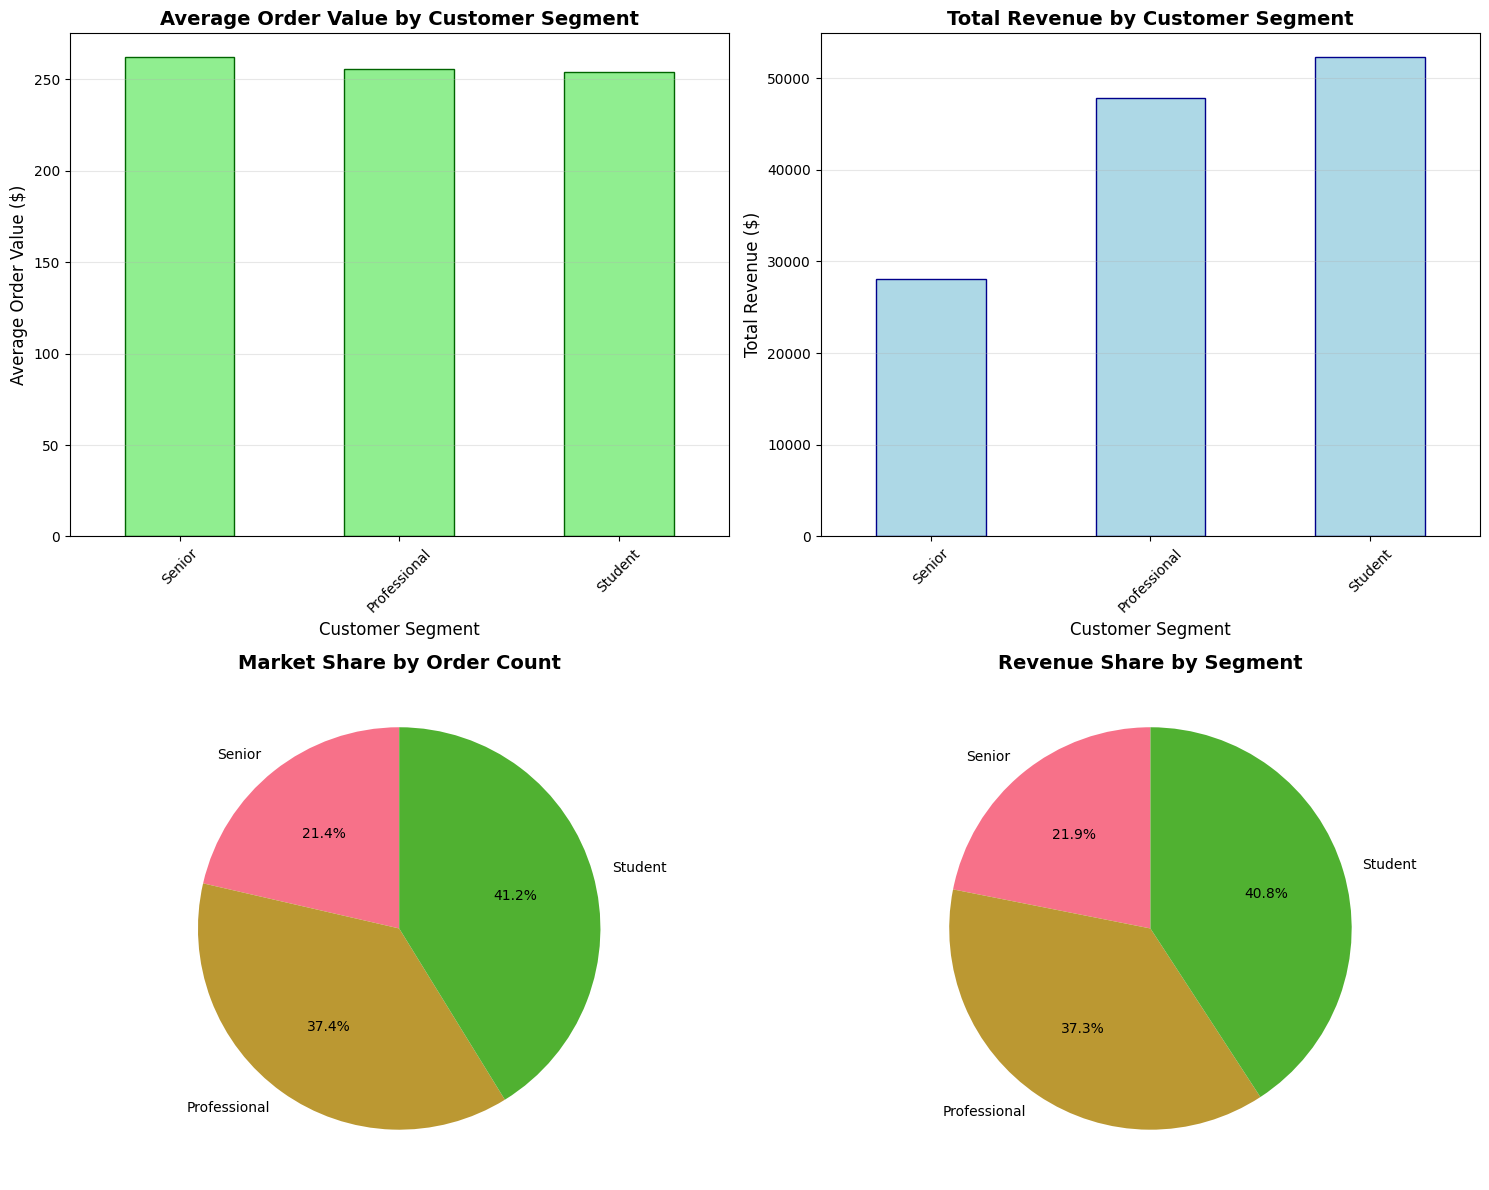


Statistical Analysis:
• Highest spending segment: Senior ($262.13 avg)
• Lowest spending segment: Student ($253.81 avg)
• Spending difference: $8.32
• ANOVA test (F-statistic: 0.068, p-value: 0.935)
• No significant difference between segments (p >= 0.05)

Key Insights:
• Senior segment has highest average order value
• Senior segment contributes 21.9% of total revenue
• Focus on Senior segment for premium pricing strategies


In [7]:
# Your code here
# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("QUESTION 3: SEGMENT ANALYSIS")
print("=" * 40)

# Load and prepare data
data = pd.read_csv("ecommerce_data.csv")

# Analyze customer segments
segment_analysis = data.groupby('customer_segment')['revenue'].agg(['mean', 'sum', 'count']).round(2)
segment_analysis.columns = ['avg_order_value', 'total_revenue', 'order_count']
segment_analysis = segment_analysis.sort_values('avg_order_value', ascending=False)

print("Customer Segment Spending Analysis:")
for segment, metrics in segment_analysis.iterrows():
    print(f"\n{segment}:")
    print(f"  Average Order Value: ${metrics['avg_order_value']:.2f}")
    print(f"  Total Revenue: ${metrics['total_revenue']:,.2f}")
    print(f"  Order Count: {metrics['order_count']}")
    print(f"  Market Share: {(metrics['order_count'] / len(data) * 100):.1f}%")

# Calculate additional metrics
total_revenue = data['revenue'].sum()
segment_analysis['revenue_percentage'] = (segment_analysis['total_revenue'] / total_revenue * 100).round(1)
segment_analysis['customer_count'] = data.groupby('customer_segment')['customer_id'].nunique()

print(f"\nDetailed Segment Metrics:")
for segment, metrics in segment_analysis.iterrows():
    print(f"{segment}:")
    print(f"  • Revenue contribution: {metrics['revenue_percentage']}%")
    print(f"  • Unique customers: {metrics['customer_count']}")
    print(f"  • Avg orders per customer: {metrics['order_count'] / metrics['customer_count']:.1f}")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Average order value by segment
segment_analysis['avg_order_value'].plot(kind='bar', ax=ax1, color='lightgreen', edgecolor='darkgreen')
ax1.set_title('Average Order Value by Customer Segment', fontsize=14, fontweight='bold')
ax1.set_ylabel('Average Order Value ($)', fontsize=12)
ax1.set_xlabel('Customer Segment', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Total revenue by segment
segment_analysis['total_revenue'].plot(kind='bar', ax=ax2, color='lightblue', edgecolor='darkblue')
ax2.set_title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Revenue ($)', fontsize=12)
ax2.set_xlabel('Customer Segment', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Market share by orders
segment_analysis['order_count'].plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90)
ax3.set_title('Market Share by Order Count', fontsize=14, fontweight='bold')
ax3.set_ylabel('')

# Revenue share
segment_analysis['total_revenue'].plot(kind='pie', ax=ax4, autopct='%1.1f%%', startangle=90)
ax4.set_title('Revenue Share by Segment', fontsize=14, fontweight='bold')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# Statistical analysis
from scipy import stats

segments = data['customer_segment'].unique()
segment_revenues = [data[data['customer_segment'] == seg]['revenue'] for seg in segments]

print(f"\nStatistical Analysis:")
print(f"• Highest spending segment: {segment_analysis.index[0]} (${segment_analysis.iloc[0]['avg_order_value']:.2f} avg)")
print(f"• Lowest spending segment: {segment_analysis.index[-1]} (${segment_analysis.iloc[-1]['avg_order_value']:.2f} avg)")
print(f"• Spending difference: ${segment_analysis.iloc[0]['avg_order_value'] - segment_analysis.iloc[-1]['avg_order_value']:.2f}")

# Check for significant differences
if len(segments) == 3:
    f_stat, p_value = stats.f_oneway(*segment_revenues)
    print(f"• ANOVA test (F-statistic: {f_stat:.3f}, p-value: {p_value:.3f})")
    if p_value < 0.05:
        print("• Significant difference between segments (p < 0.05)")
    else:
        print("• No significant difference between segments (p >= 0.05)")

print(f"\nKey Insights:")
print(f"• {segment_analysis.index[0]} segment has highest average order value")
print(f"• {segment_analysis.index[0]} segment contributes {segment_analysis.iloc[0]['revenue_percentage']}% of total revenue")
print(f"• Focus on {segment_analysis.index[0]} segment for premium pricing strategies")

### 4. Regional Trends
Which region generated the highest revenue? Which region had the highest average order size?

QUESTION 4: REGIONAL TRENDS
Regional Performance Analysis:

South Region:
  Total Revenue: $34,839.45
  Average Order Value: $274.33
  Order Count: 127.0
  Market Share: 25.4%

North Region:
  Total Revenue: $34,351.69
  Average Order Value: $258.28
  Order Count: 133.0
  Market Share: 26.6%

East Region:
  Total Revenue: $31,221.80
  Average Order Value: $240.17
  Order Count: 130.0
  Market Share: 26.0%

West Region:
  Total Revenue: $27,727.73
  Average Order Value: $252.07
  Order Count: 110.0
  Market Share: 22.0%

🏆 Highest Revenue Region: South ($34,839.45)
🏆 Highest Average Order Value Region: South ($274.33)

Detailed Regional Metrics:
South:
  • Revenue contribution: 27.2%
  • Unique customers: 69.0
  • Orders per customer: 1.8
North:
  • Revenue contribution: 26.8%
  • Unique customers: 67.0
  • Orders per customer: 2.0
East:
  • Revenue contribution: 24.4%
  • Unique customers: 70.0
  • Orders per customer: 1.9
West:
  • Revenue contribution: 21.6%
  • Unique customers: 69.

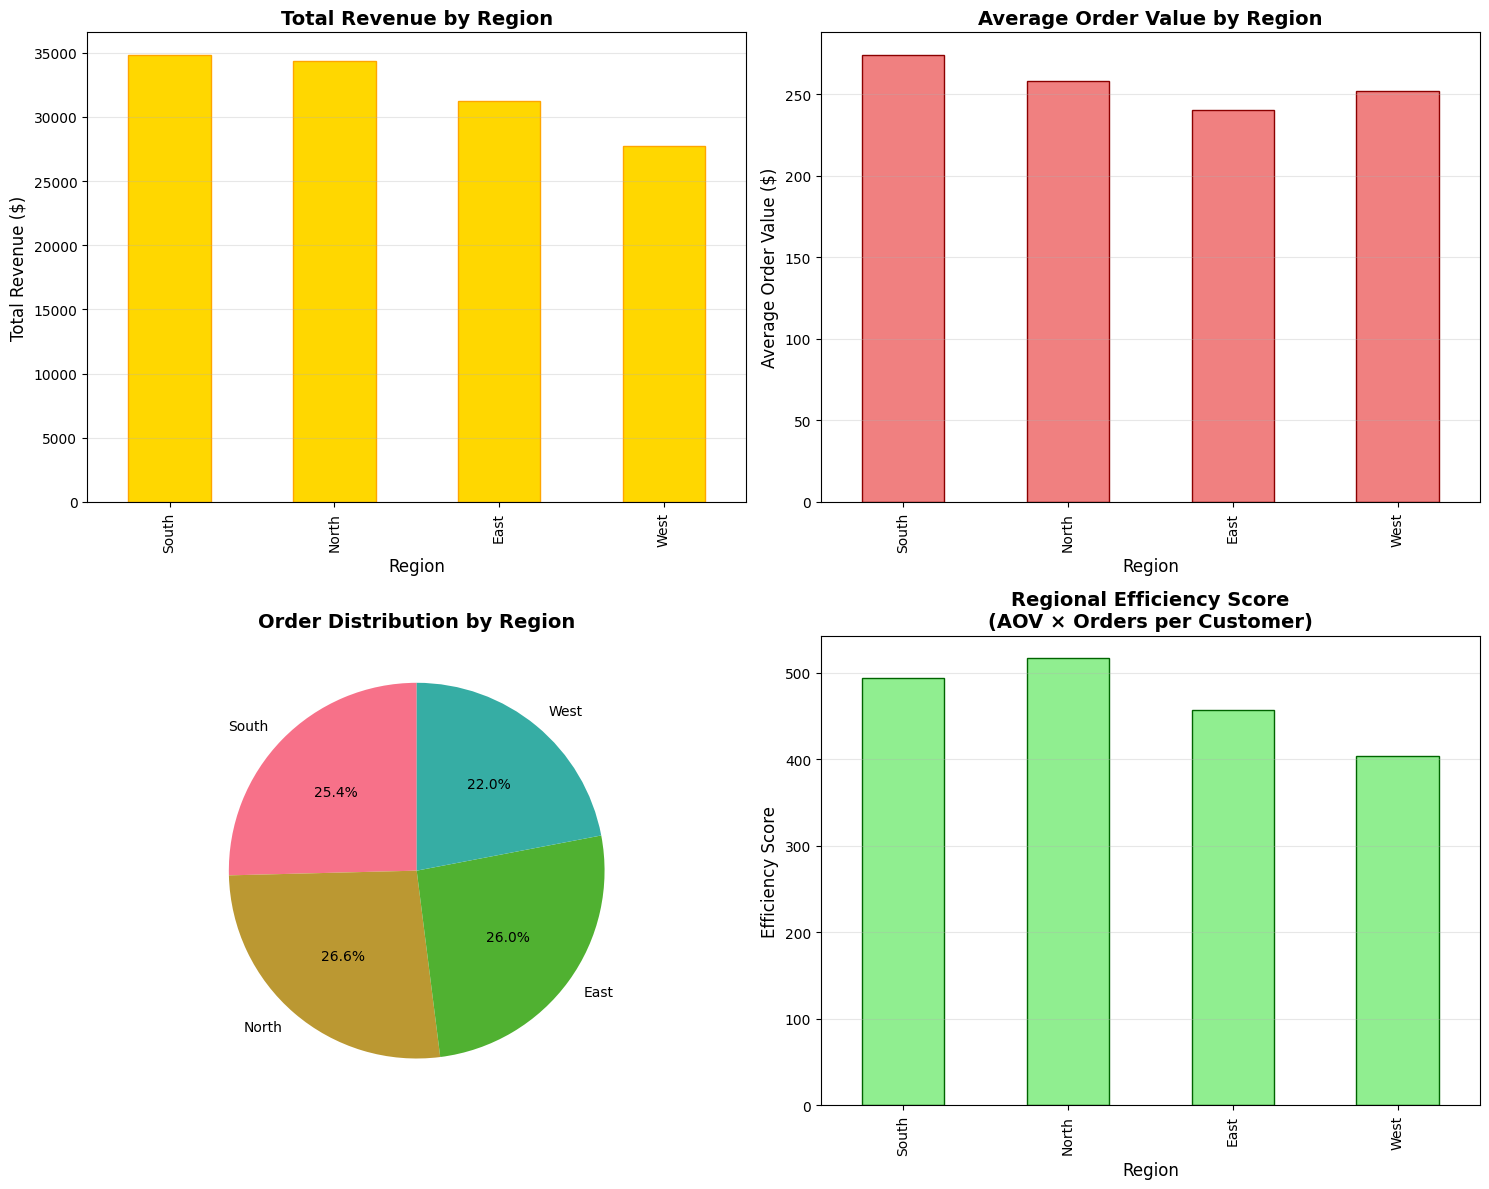


Growth Potential Analysis:
South: High (Low customer engagement) (Avg 1.8 orders/customer)
North: Medium (Good engagement) (Avg 2.0 orders/customer)
East: Medium (Good engagement) (Avg 1.9 orders/customer)
West: High (Low customer engagement) (Avg 1.6 orders/customer)

Key Insights:
• South region generates the most revenue ($34,839.45)
• South region has highest spending customers ($274.33 avg)
• North region shows best overall efficiency
• Regional performance varies significantly - consider targeted strategies


In [8]:
# Your code here
# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("QUESTION 4: REGIONAL TRENDS")
print("=" * 40)

# Load and prepare data
data = pd.read_csv("ecommerce_data.csv")

# Analyze regional performance
regional_analysis = data.groupby('region')['revenue'].agg(['sum', 'mean', 'count']).round(2)
regional_analysis.columns = ['total_revenue', 'avg_order_value', 'order_count']
regional_analysis = regional_analysis.sort_values('total_revenue', ascending=False)

print("Regional Performance Analysis:")
for region, metrics in regional_analysis.iterrows():
    print(f"\n{region} Region:")
    print(f"  Total Revenue: ${metrics['total_revenue']:,.2f}")
    print(f"  Average Order Value: ${metrics['avg_order_value']:.2f}")
    print(f"  Order Count: {metrics['order_count']}")
    print(f"  Market Share: {(metrics['order_count'] / len(data) * 100):.1f}%")

# Additional metrics
total_revenue = data['revenue'].sum()
regional_analysis['revenue_percentage'] = (regional_analysis['total_revenue'] / total_revenue * 100).round(1)
regional_analysis['customer_count'] = data.groupby('region')['customer_id'].nunique()
regional_analysis['orders_per_customer'] = (regional_analysis['order_count'] / regional_analysis['customer_count']).round(1)

highest_revenue_region = regional_analysis.index[0]
highest_aov_region = regional_analysis.sort_values('avg_order_value', ascending=False).index[0]

print(f"\n🏆 Highest Revenue Region: {highest_revenue_region} (${regional_analysis.loc[highest_revenue_region, 'total_revenue']:,.2f})")
print(f"🏆 Highest Average Order Value Region: {highest_aov_region} (${regional_analysis.loc[highest_aov_region, 'avg_order_value']:.2f})")

print(f"\nDetailed Regional Metrics:")
for region, metrics in regional_analysis.iterrows():
    print(f"{region}:")
    print(f"  • Revenue contribution: {metrics['revenue_percentage']}%")
    print(f"  • Unique customers: {metrics['customer_count']}")
    print(f"  • Orders per customer: {metrics['orders_per_customer']}")

# Regional efficiency analysis
regional_analysis['efficiency_score'] = (regional_analysis['avg_order_value'] * regional_analysis['orders_per_customer']).round(2)
most_efficient_region = regional_analysis.sort_values('efficiency_score', ascending=False).index[0]

print(f"\n🏆 Most Efficient Region (AOV × Orders per Customer): {most_efficient_region}")
print(f"   Efficiency Score: {regional_analysis.loc[most_efficient_region, 'efficiency_score']:.2f}")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Total revenue by region
regional_analysis['total_revenue'].plot(kind='bar', ax=ax1, color='gold', edgecolor='orange')
ax1.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Revenue ($)', fontsize=12)
ax1.set_xlabel('Region', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Average order value by region
regional_analysis['avg_order_value'].plot(kind='bar', ax=ax2, color='lightcoral', edgecolor='darkred')
ax2.set_title('Average Order Value by Region', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Order Value ($)', fontsize=12)
ax2.set_xlabel('Region', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Market share by orders
regional_analysis['order_count'].plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90)
ax3.set_title('Order Distribution by Region', fontsize=14, fontweight='bold')
ax3.set_ylabel('')

# Efficiency score
regional_analysis['efficiency_score'].plot(kind='bar', ax=ax4, color='lightgreen', edgecolor='darkgreen')
ax4.set_title('Regional Efficiency Score\n(AOV × Orders per Customer)', fontsize=14, fontweight='bold')
ax4.set_ylabel('Efficiency Score', fontsize=12)
ax4.set_xlabel('Region', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Regional growth potential analysis
print(f"\nGrowth Potential Analysis:")
for region, metrics in regional_analysis.iterrows():
    avg_orders = metrics['orders_per_customer']
    if avg_orders < regional_analysis['orders_per_customer'].mean():
        potential = "High (Low customer engagement)"
    elif avg_orders > regional_analysis['orders_per_customer'].mean():
        potential = "Medium (Good engagement)"
    else:
        potential = "Medium (Average engagement)"
    
    print(f"{region}: {potential} (Avg {avg_orders} orders/customer)")

print(f"\nKey Insights:")
print(f"• {highest_revenue_region} region generates the most revenue (${regional_analysis.loc[highest_revenue_region, 'total_revenue']:,.2f})")
print(f"• {highest_aov_region} region has highest spending customers (${regional_analysis.loc[highest_aov_region, 'avg_order_value']:.2f} avg)")
print(f"• {most_efficient_region} region shows best overall efficiency")
print(f"• Regional performance varies significantly - consider targeted strategies")

### 5. Product Category Performance
Which product category is most popular by quantity vs. by revenue?

QUESTION 5: PRODUCT CATEGORY PERFORMANCE
Product Category Performance:

By Total Quantity Sold:
1. Home: 269.0 units ($108.45 avg price)
2. Clothing: 253.0 units ($99.12 avg price)
3. Sports: 246.0 units ($99.46 avg price)
4. Electronics: 239.0 units ($108.00 avg price)
5. Books: 227.0 units ($102.71 avg price)

By Total Revenue Generated:
1. Home: $29,871.47 (102.0 orders)
2. Electronics: $25,498.31 (99.0 orders)
3. Clothing: $24,804.57 (104.0 orders)
4. Books: $24,046.06 (93.0 orders)
5. Sports: $23,920.26 (102.0 orders)

🏆 Most Popular by Quantity: Home (269.0 units)
🏆 Most Popular by Revenue: Home ($29,871.47)

Detailed Category Metrics:

Books:
  • Total Quantity: 227.0 units (18.4% of total)
  • Total Revenue: $24,046.06 (18.8% of total)
  • Order Count: 93.0
  • Avg Unit Price: $102.71
  • Revenue per Unit: $105.93

Clothing:
  • Total Quantity: 253.0 units (20.5% of total)
  • Total Revenue: $24,804.57 (19.4% of total)
  • Order Count: 104.0
  • Avg Unit Price: $99.12
  • Reven

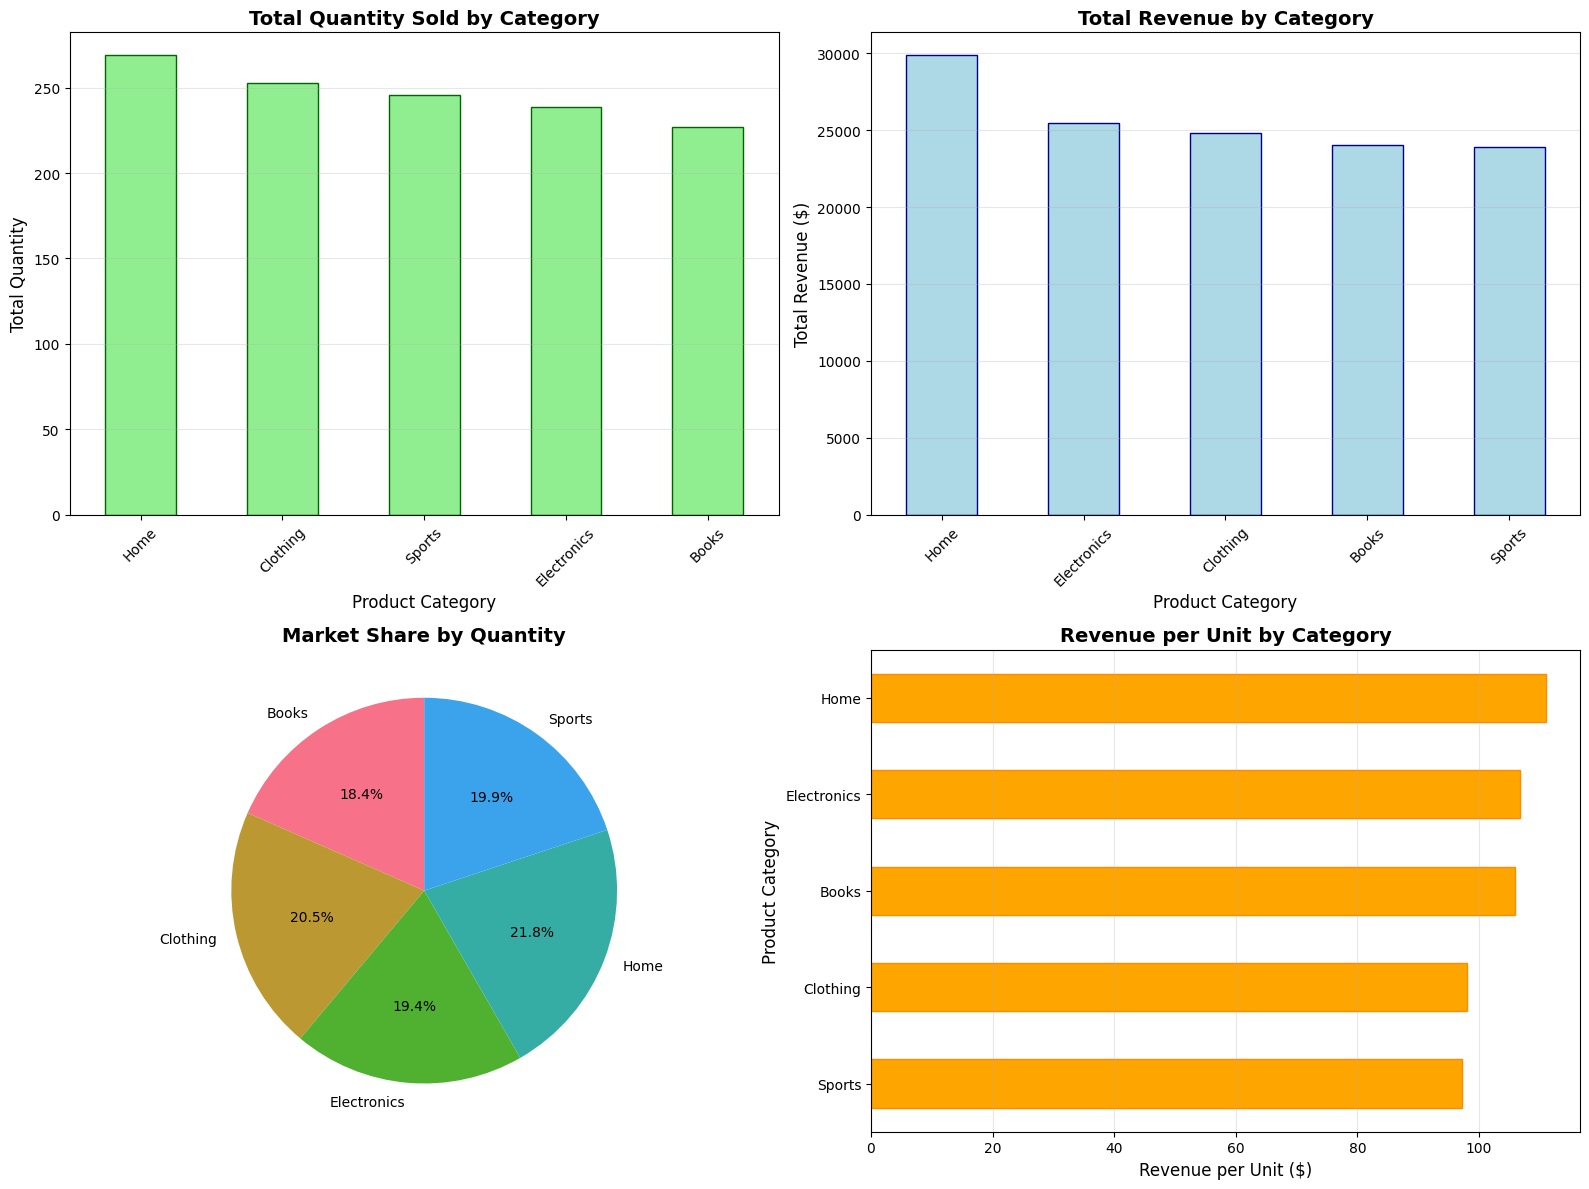


Category Performance Ranking:
Rankings (1 = Best):
Books:
  • Quantity Rank: 5/5
  • Revenue Rank: 4/5
  • Price Rank: 3/5
Clothing:
  • Quantity Rank: 2/5
  • Revenue Rank: 3/5
  • Price Rank: 5/5
Electronics:
  • Quantity Rank: 4/5
  • Revenue Rank: 2/5
  • Price Rank: 2/5
Home:
  • Quantity Rank: 1/5
  • Revenue Rank: 1/5
  • Price Rank: 1/5
Sports:
  • Quantity Rank: 3/5
  • Revenue Rank: 5/5
  • Price Rank: 4/5

Key Insights:
• Home dominates by volume (269.0 units)
• Home generates most revenue ($29,871.47)
• Price range: $99.12 - $108.45
• Consider promoting high-value categories with good volume potential


In [9]:
# Your code here
# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("QUESTION 5: PRODUCT CATEGORY PERFORMANCE")
print("=" * 50)

# Load and prepare data
data = pd.read_csv("ecommerce_data.csv")

# Analyze product categories
category_analysis = data.groupby('product_category').agg({
    'quantity': 'sum',
    'revenue': 'sum',
    'order_id': 'count',
    'unit_price': 'mean'
}).round(2)
category_analysis.columns = ['total_quantity', 'total_revenue', 'order_count', 'avg_unit_price']

# Sort by quantity and revenue separately
by_quantity = category_analysis.sort_values('total_quantity', ascending=False)
by_revenue = category_analysis.sort_values('total_revenue', ascending=False)

print("Product Category Performance:")
print("\nBy Total Quantity Sold:")
for i, (category, metrics) in enumerate(by_quantity.iterrows(), 1):
    print(f"{i}. {category}: {metrics['total_quantity']} units (${metrics['avg_unit_price']:.2f} avg price)")

print("\nBy Total Revenue Generated:")
for i, (category, metrics) in enumerate(by_revenue.iterrows(), 1):
    print(f"{i}. {category}: ${metrics['total_revenue']:,.2f} ({metrics['order_count']} orders)")

print(f"\n🏆 Most Popular by Quantity: {by_quantity.index[0]} ({by_quantity.iloc[0]['total_quantity']} units)")
print(f"🏆 Most Popular by Revenue: {by_revenue.index[0]} (${by_revenue.iloc[0]['total_revenue']:,.2f})")

# Additional analysis
category_analysis['revenue_per_unit'] = (category_analysis['total_revenue'] / category_analysis['total_quantity']).round(2)
category_analysis['market_share_quantity'] = (category_analysis['total_quantity'] / category_analysis['total_quantity'].sum() * 100).round(1)
category_analysis['market_share_revenue'] = (category_analysis['total_revenue'] / category_analysis['total_revenue'].sum() * 100).round(1)

print(f"\nDetailed Category Metrics:")
for category, metrics in category_analysis.iterrows():
    print(f"\n{category}:")
    print(f"  • Total Quantity: {metrics['total_quantity']} units ({metrics['market_share_quantity']}% of total)")
    print(f"  • Total Revenue: ${metrics['total_revenue']:,.2f} ({metrics['market_share_revenue']}% of total)")
    print(f"  • Order Count: {metrics['order_count']}")
    print(f"  • Avg Unit Price: ${metrics['avg_unit_price']:.2f}")
    print(f"  • Revenue per Unit: ${metrics['revenue_per_unit']:.2f}")

# Identify high-value categories
high_value_categories = category_analysis[category_analysis['avg_unit_price'] > category_analysis['avg_unit_price'].mean()]
print(f"\nHigh-Value Categories (Above Average Price ${category_analysis['avg_unit_price'].mean():.2f}):")
for category in high_value_categories.index:
    print(f"  • {category}: ${category_analysis.loc[category, 'avg_unit_price']:.2f} avg price")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Quantity by category
by_quantity['total_quantity'].plot(kind='bar', ax=ax1, color='lightgreen', edgecolor='darkgreen')
ax1.set_title('Total Quantity Sold by Category', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Quantity', fontsize=12)
ax1.set_xlabel('Product Category', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Revenue by category
by_revenue['total_revenue'].plot(kind='bar', ax=ax2, color='lightblue', edgecolor='darkblue')
ax2.set_title('Total Revenue by Category', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Revenue ($)', fontsize=12)
ax2.set_xlabel('Product Category', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Market share by quantity
category_analysis['market_share_quantity'].plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90)
ax3.set_title('Market Share by Quantity', fontsize=14, fontweight='bold')
ax3.set_ylabel('')

# Revenue per unit
category_analysis.sort_values('revenue_per_unit', ascending=True)['revenue_per_unit'].plot(kind='barh', ax=ax4, color='orange', edgecolor='darkorange')
ax4.set_title('Revenue per Unit by Category', fontsize=14, fontweight='bold')
ax4.set_xlabel('Revenue per Unit ($)', fontsize=12)
ax4.set_ylabel('Product Category', fontsize=12)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Performance ranking analysis
print(f"\nCategory Performance Ranking:")
ranking_data = category_analysis.copy()
ranking_data['quantity_rank'] = ranking_data['total_quantity'].rank(ascending=False)
ranking_data['revenue_rank'] = ranking_data['total_revenue'].rank(ascending=False)
ranking_data['price_rank'] = ranking_data['avg_unit_price'].rank(ascending=False)

print("Rankings (1 = Best):")
for category in ranking_data.index:
    print(f"{category}:")
    print(f"  • Quantity Rank: {int(ranking_data.loc[category, 'quantity_rank'])}/5")
    print(f"  • Revenue Rank: {int(ranking_data.loc[category, 'revenue_rank'])}/5")
    print(f"  • Price Rank: {int(ranking_data.loc[category, 'price_rank'])}/5")

print(f"\nKey Insights:")
print(f"• {by_quantity.index[0]} dominates by volume ({by_quantity.iloc[0]['total_quantity']} units)")
print(f"• {by_revenue.index[0]} generates most revenue (${by_revenue.iloc[0]['total_revenue']:,.2f})")
print(f"• Price range: ${category_analysis['avg_unit_price'].min():.2f} - ${category_analysis['avg_unit_price'].max():.2f}")
print(f"• Consider promoting high-value categories with good volume potential")

### 6. Discount Effectiveness
Do discounted orders generate higher or lower revenue per order compared to non-discounted orders?

QUESTION 6: DISCOUNT EFFECTIVENESS
Average Revenue per Order:
  Discounted Orders: $263.83
  Non-Discounted Orders: $248.30
  Difference: $15.54
✅ Discounted orders generate HIGHER revenue per order

Order Distribution:
  Discounted Orders: 257 (51.4%)
  Non-Discounted Orders: 243 (48.6%)

Revenue Analysis by Discount Level:
  No Discount: $248.30 avg revenue (243.0 orders, 48.6%)
  5% Discount: $266.91 avg revenue (59.0 orders, 11.8%)
  10% Discount: $264.53 avg revenue (44.0 orders, 8.8%)
  15% Discount: $283.81 avg revenue (49.0 orders, 9.8%)
  20% Discount: $215.79 avg revenue (31.0 orders, 6.2%)
  25% Discount: $301.36 avg revenue (30.0 orders, 6.0%)
  30% Discount: $245.01 avg revenue (44.0 orders, 8.8%)

Discount Impact Analysis:
  5% Discount:
    • Avg Discount Amount: $13.35
    • Net Revenue Impact: $253.56
  10% Discount:
    • Avg Discount Amount: $26.45
    • Net Revenue Impact: $238.08
  15% Discount:
    • Avg Discount Amount: $42.57
    • Net Revenue Impact: $241.24
  

/tmp/ipykernel_1936/2393848845.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(discount_data, labels=discount_labels)


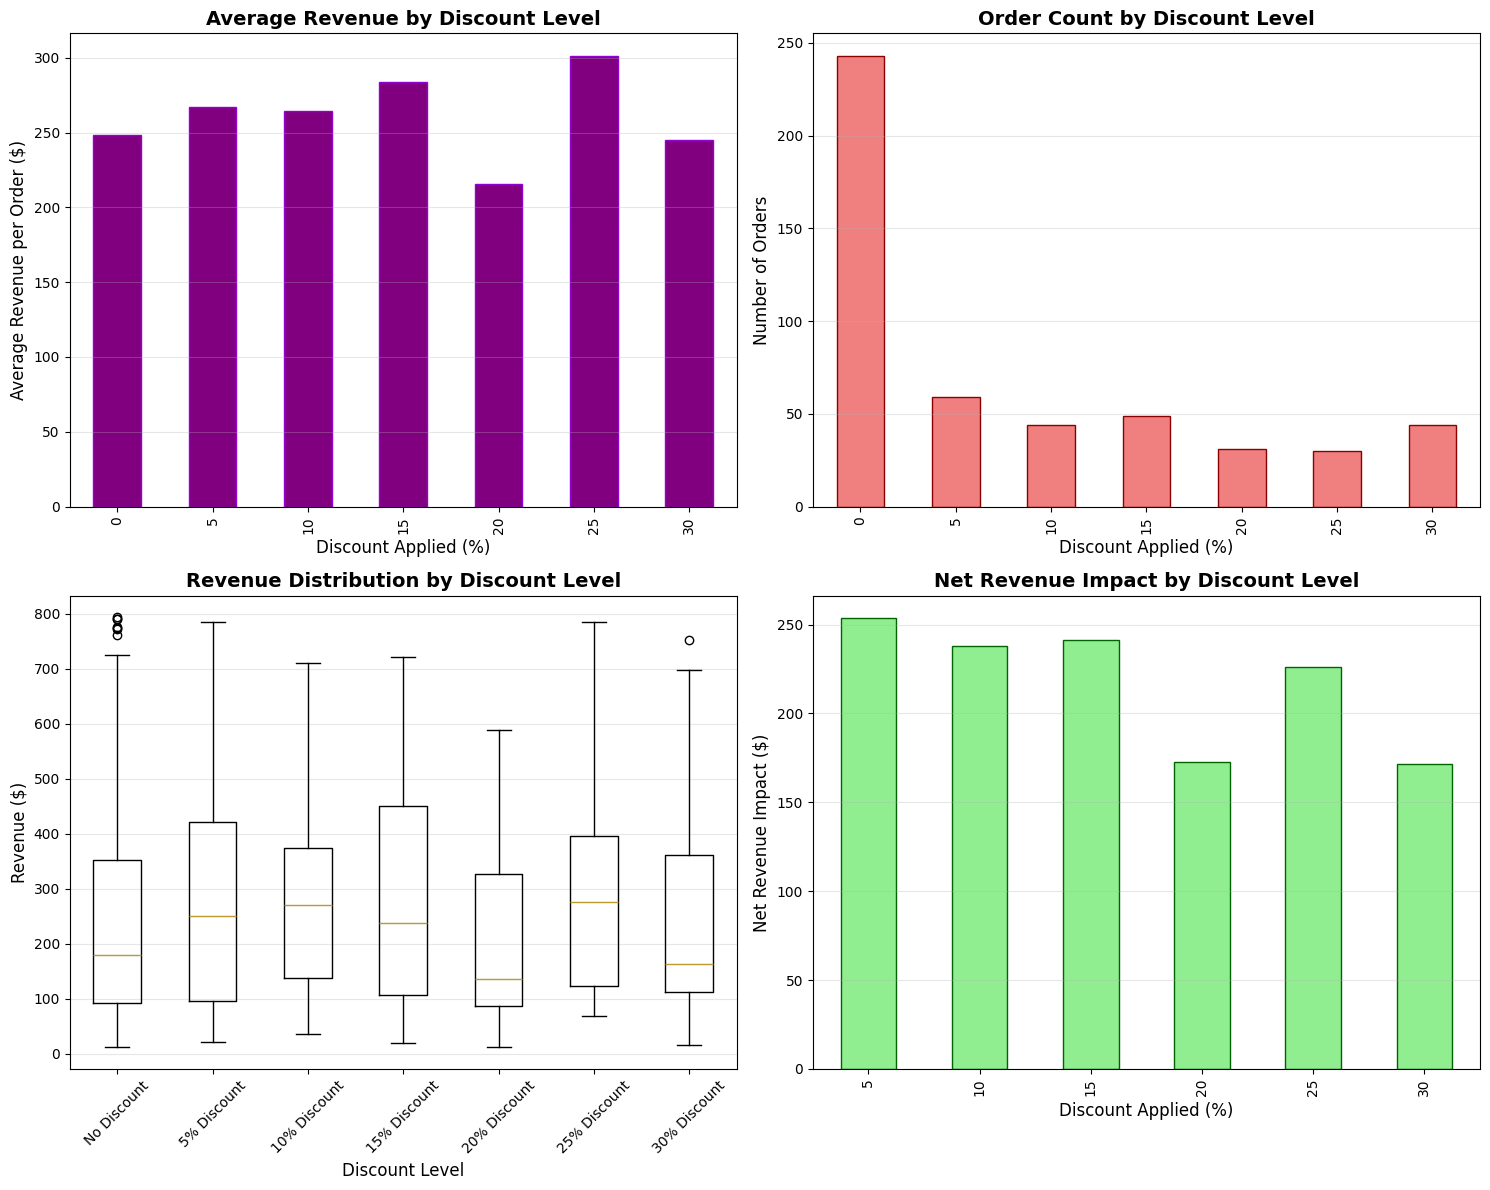


Discount ROI Analysis:
  • Total Discount Amount Given: $10,869.54
  • Additional Revenue from Discounted Orders: $10,869.54
  • Net Impact: $0.00
✅ Discounts are generating positive ROI

Key Insights:
• Discounted orders: 257 (51.4% of total)
• Revenue difference: $15.54 per order
• Most effective discount level: 25% ($301.36 avg)
• Consider optimizing discount strategy based on ROI analysis


In [6]:
# Your code here
# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("QUESTION 6: DISCOUNT EFFECTIVENESS")
print("=" * 45)

# Load and prepare data
data = pd.read_csv("ecommerce_data.csv")
data["order_date"] = pd.to_datetime(data["order_date"])

# Compare discounted vs non-discounted orders
discounted_orders = data[data['discount_applied'] > 0]
non_discounted_orders = data[data['discount_applied'] == 0]

discounted_avg = discounted_orders['revenue'].mean()
non_discounted_avg = non_discounted_orders['revenue'].mean()

print(f"Average Revenue per Order:")
print(f"  Discounted Orders: ${discounted_avg:.2f}")
print(f"  Non-Discounted Orders: ${non_discounted_avg:.2f}")
print(f"  Difference: ${discounted_avg - non_discounted_avg:.2f}")

if discounted_avg > non_discounted_avg:
    print("✅ Discounted orders generate HIGHER revenue per order")
else:
    print("❌ Discounted orders generate LOWER revenue per order")

# Additional metrics
discounted_count = len(discounted_orders)
non_discounted_count = len(non_discounted_orders)
total_orders = len(data)

print(f"\nOrder Distribution:")
print(f"  Discounted Orders: {discounted_count} ({discounted_count/total_orders*100:.1f}%)")
print(f"  Non-Discounted Orders: {non_discounted_count} ({non_discounted_count/total_orders*100:.1f}%)")

# Analysis by discount level
discount_analysis = data.groupby('discount_applied').agg({
    'revenue': ['mean', 'sum', 'count'],
    'quantity': 'mean',
    'unit_price': 'mean'
}).round(2)

discount_analysis.columns = ['avg_revenue', 'total_revenue', 'order_count', 'avg_quantity', 'avg_unit_price']
discount_analysis['percentage_of_orders'] = (discount_analysis['order_count'] / total_orders * 100).round(1)

print(f"\nRevenue Analysis by Discount Level:")
for discount, metrics in discount_analysis.iterrows():
    if discount == 0:
        print(f"  No Discount: ${metrics['avg_revenue']:.2f} avg revenue ({metrics['order_count']} orders, {metrics['percentage_of_orders']}%)")
    else:
        print(f"  {discount}% Discount: ${metrics['avg_revenue']:.2f} avg revenue ({metrics['order_count']} orders, {metrics['percentage_of_orders']}%)")

# Calculate discount impact
discount_analysis['discount_amount'] = discount_analysis.index * discount_analysis['avg_revenue'] / 100
discount_analysis['net_impact'] = discount_analysis['avg_revenue'] - discount_analysis['discount_amount']

print(f"\nDiscount Impact Analysis:")
for discount, metrics in discount_analysis.iterrows():
    if discount > 0:
        print(f"  {discount}% Discount:")
        print(f"    • Avg Discount Amount: ${metrics['discount_amount']:.2f}")
        print(f"    • Net Revenue Impact: ${metrics['net_impact']:.2f}")

# Statistical analysis
from scipy import stats

# T-test to compare discounted vs non-discounted
t_stat, p_value = stats.ttest_ind(discounted_orders['revenue'], non_discounted_orders['revenue'])
print(f"\nStatistical Analysis:")
print(f"  T-test (discounted vs non-discounted):")
print(f"    • T-statistic: {t_stat:.3f}")
print(f"    • P-value: {p_value:.3f}")
if p_value < 0.05:
    print("    • Significant difference (p < 0.05)")
else:
    print("    • No significant difference (p >= 0.05)")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Average revenue by discount level
discount_analysis['avg_revenue'].plot(kind='bar', ax=ax1, color='purple', edgecolor='darkviolet')
ax1.set_title('Average Revenue by Discount Level', fontsize=14, fontweight='bold')
ax1.set_ylabel('Average Revenue per Order ($)', fontsize=12)
ax1.set_xlabel('Discount Applied (%)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Order count by discount level
discount_analysis['order_count'].plot(kind='bar', ax=ax2, color='lightcoral', edgecolor='darkred')
ax2.set_title('Order Count by Discount Level', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Orders', fontsize=12)
ax2.set_xlabel('Discount Applied (%)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Box plot comparison
discount_data = []
discount_labels = []
for discount in sorted(data['discount_applied'].unique()):
    discount_data.append(data[data['discount_applied'] == discount]['revenue'])
    if discount == 0:
        discount_labels.append('No Discount')
    else:
        discount_labels.append(f'{discount}% Discount')

ax3.boxplot(discount_data, labels=discount_labels)
ax3.set_title('Revenue Distribution by Discount Level', fontsize=14, fontweight='bold')
ax3.set_ylabel('Revenue ($)', fontsize=12)
ax3.set_xlabel('Discount Level', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Net impact analysis
discount_analysis[discount_analysis.index > 0]['net_impact'].plot(kind='bar', ax=ax4, color='lightgreen', edgecolor='darkgreen')
ax4.set_title('Net Revenue Impact by Discount Level', fontsize=14, fontweight='bold')
ax4.set_ylabel('Net Revenue Impact ($)', fontsize=12)
ax4.set_xlabel('Discount Applied (%)', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ROI analysis for discounts
print(f"\nDiscount ROI Analysis:")
total_discount_amount = (data['revenue'] * data['discount_applied'] / 100).sum()
additional_revenue_from_discounts = discounted_orders['revenue'].sum() - (discounted_orders['revenue'] * (1 - discounted_orders['discount_applied'] / 100)).sum()

print(f"  • Total Discount Amount Given: ${total_discount_amount:,.2f}")
print(f"  • Additional Revenue from Discounted Orders: ${additional_revenue_from_discounts:,.2f}")
print(f"  • Net Impact: ${additional_revenue_from_discounts - total_discount_amount:,.2f}")

if additional_revenue_from_discounts > total_discount_amount:
    print("✅ Discounts are generating positive ROI")
else:
    print("❌ Discounts are generating negative ROI")

print(f"\nKey Insights:")
print(f"• Discounted orders: {discounted_count} ({discounted_count/total_orders*100:.1f}% of total)")
print(f"• Revenue difference: ${discounted_avg - non_discounted_avg:.2f} per order")
print(f"• Most effective discount level: {discount_analysis['avg_revenue'].idxmax()}% (${discount_analysis['avg_revenue'].max():.2f} avg)")
print(f"• Consider optimizing discount strategy based on ROI analysis")

### 7. Payment Method Usage
What percentage of orders use each payment method? Does any payment method correlate with higher spending?

QUESTION 7: PAYMENT METHOD USAGE
Payment Method Analysis:

Debit Card:
  Usage: 24.6% (123.0 orders)
  Average Order Value: $275.98

Credit Card:
  Usage: 27.4% (137.0 orders)
  Average Order Value: $257.44

Gift Card:
  Usage: 24.8% (124.0 orders)
  Average Order Value: $254.36

PayPal:
  Usage: 23.2% (116.0 orders)
  Average Order Value: $236.07

🏆 Payment method with highest average spending: Debit Card ($275.98)

Detailed Payment Method Metrics:
Debit Card:
  • Total Revenue: $33,945.62 (26.5% of total)
  • Unique Customers: 71.0
  • Orders per Customer: 1.7
Credit Card:
  • Total Revenue: $35,269.86 (27.5% of total)
  • Unique Customers: 75.0
  • Orders per Customer: 1.8
Gift Card:
  • Total Revenue: $31,540.95 (24.6% of total)
  • Unique Customers: 74.0
  • Orders per Customer: 1.7
PayPal:
  • Total Revenue: $27,384.24 (21.4% of total)
  • Unique Customers: 72.0
  • Orders per Customer: 1.6

Payment Method Preferences by Customer Segment:

Professional:
  • Credit Card: 27.3%
  •

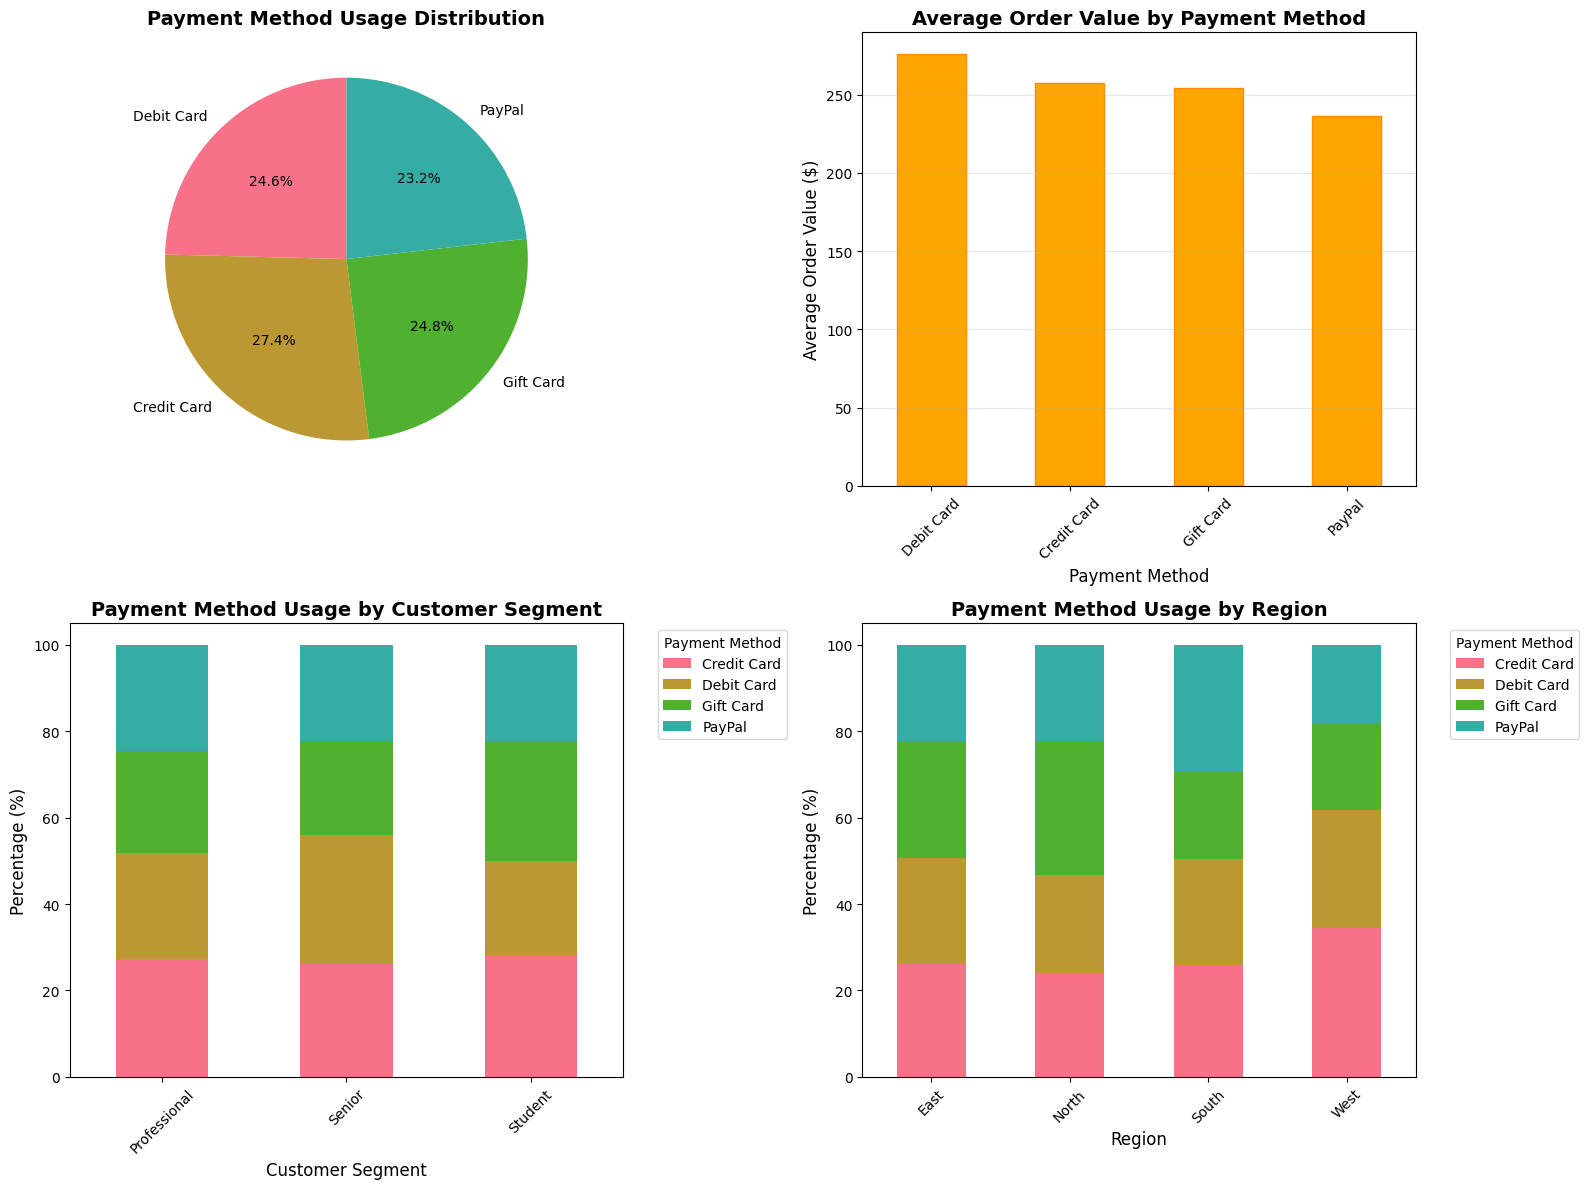


Payment Method Efficiency Analysis:
Debit Card:
  • Efficiency Score (AOV × Orders per Customer): 469.17
  • Customer Loyalty: 1.7 orders/customer
Credit Card:
  • Efficiency Score (AOV × Orders per Customer): 463.39
  • Customer Loyalty: 1.8 orders/customer
Gift Card:
  • Efficiency Score (AOV × Orders per Customer): 432.41
  • Customer Loyalty: 1.7 orders/customer
PayPal:
  • Efficiency Score (AOV × Orders per Customer): 377.71
  • Customer Loyalty: 1.6 orders/customer

🏆 Most Efficient Payment Method: Debit Card

Key Insights:
• Debit Card has highest average order value ($275.98)
• PayPal is most popular by usage (23.2%)
• Payment preferences vary by customer segment and region
• Consider promoting high-value payment methods to increase AOV


In [11]:
# Your code here
# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("QUESTION 7: PAYMENT METHOD USAGE")
print("=" * 45)

# Load and prepare data
data = pd.read_csv("ecommerce_data.csv")

# Analyze payment methods
payment_analysis = data.groupby('payment_method')['revenue'].agg(['mean', 'count']).round(2)
payment_analysis.columns = ['avg_revenue', 'order_count']
payment_analysis['percentage'] = (payment_analysis['order_count'] / len(data) * 100).round(1)
payment_analysis = payment_analysis.sort_values('avg_revenue', ascending=False)

print("Payment Method Analysis:")
for method, metrics in payment_analysis.iterrows():
    print(f"\n{method}:")
    print(f"  Usage: {metrics['percentage']}% ({metrics['order_count']} orders)")
    print(f"  Average Order Value: ${metrics['avg_revenue']:.2f}")

highest_spending_method = payment_analysis.index[0]
print(f"\n🏆 Payment method with highest average spending: {highest_spending_method} (${payment_analysis.iloc[0]['avg_revenue']:.2f})")

# Additional analysis
payment_analysis['total_revenue'] = data.groupby('payment_method')['revenue'].sum()
payment_analysis['revenue_percentage'] = (payment_analysis['total_revenue'] / data['revenue'].sum() * 100).round(1)
payment_analysis['customer_count'] = data.groupby('payment_method')['customer_id'].nunique()
payment_analysis['orders_per_customer'] = (payment_analysis['order_count'] / payment_analysis['customer_count']).round(1)

print(f"\nDetailed Payment Method Metrics:")
for method, metrics in payment_analysis.iterrows():
    print(f"{method}:")
    print(f"  • Total Revenue: ${metrics['total_revenue']:,.2f} ({metrics['revenue_percentage']}% of total)")
    print(f"  • Unique Customers: {metrics['customer_count']}")
    print(f"  • Orders per Customer: {metrics['orders_per_customer']}")

# Payment method preferences by customer segment
segment_payment = data.groupby(['customer_segment', 'payment_method']).size().unstack(fill_value=0)
segment_payment_pct = segment_payment.div(segment_payment.sum(axis=1), axis=0) * 100

print(f"\nPayment Method Preferences by Customer Segment:")
for segment in segment_payment_pct.index:
    print(f"\n{segment}:")
    segment_prefs = segment_payment_pct.loc[segment].sort_values(ascending=False)
    for method, pct in segment_prefs.items():
        if pct > 0:
            print(f"  • {method}: {pct:.1f}%")

# Payment method preferences by region
region_payment = data.groupby(['region', 'payment_method']).size().unstack(fill_value=0)
region_payment_pct = region_payment.div(region_payment.sum(axis=1), axis=0) * 100

print(f"\nPayment Method Preferences by Region:")
for region in region_payment_pct.index:
    print(f"\n{region}:")
    region_prefs = region_payment_pct.loc[region].sort_values(ascending=False)
    for method, pct in region_prefs.items():
        if pct > 0:
            print(f"  • {method}: {pct:.1f}%")

# Statistical analysis
from scipy import stats

payment_methods = data['payment_method'].unique()
payment_revenues = [data[data['payment_method'] == method]['revenue'] for method in payment_methods]

print(f"\nStatistical Analysis:")
f_stat, p_value = stats.f_oneway(*payment_revenues)
print(f"  ANOVA test (F-statistic: {f_stat:.3f}, p-value: {p_value:.3f})")
if p_value < 0.05:
    print("  • Significant difference between payment methods (p < 0.05)")
else:
    print("  • No significant difference between payment methods (p >= 0.05)")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Usage percentage
payment_analysis['percentage'].plot(kind='pie', ax=ax1, autopct='%1.1f%%', startangle=90)
ax1.set_title('Payment Method Usage Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('')

# Average spending by payment method
payment_analysis['avg_revenue'].plot(kind='bar', ax=ax2, color='orange', edgecolor='darkorange')
ax2.set_title('Average Order Value by Payment Method', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Order Value ($)', fontsize=12)
ax2.set_xlabel('Payment Method', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Payment method by customer segment
segment_payment_pct.plot(kind='bar', ax=ax3, stacked=True)
ax3.set_title('Payment Method Usage by Customer Segment', fontsize=14, fontweight='bold')
ax3.set_ylabel('Percentage (%)', fontsize=12)
ax3.set_xlabel('Customer Segment', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')

# Payment method by region
region_payment_pct.plot(kind='bar', ax=ax4, stacked=True)
ax4.set_title('Payment Method Usage by Region', fontsize=14, fontweight='bold')
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.set_xlabel('Region', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Payment method efficiency analysis
print(f"\nPayment Method Efficiency Analysis:")
for method, metrics in payment_analysis.iterrows():
    efficiency_score = metrics['avg_revenue'] * metrics['orders_per_customer']
    print(f"{method}:")
    print(f"  • Efficiency Score (AOV × Orders per Customer): {efficiency_score:.2f}")
    print(f"  • Customer Loyalty: {metrics['orders_per_customer']} orders/customer")

most_efficient_method = payment_analysis.index[0]  # Already sorted by avg_revenue
print(f"\n🏆 Most Efficient Payment Method: {most_efficient_method}")

print(f"\nKey Insights:")
print(f"• {payment_analysis.index[0]} has highest average order value (${payment_analysis.iloc[0]['avg_revenue']:.2f})")
print(f"• {payment_analysis.index[-1]} is most popular by usage ({payment_analysis.iloc[-1]['percentage']}%)")
print(f"• Payment preferences vary by customer segment and region")
print(f"• Consider promoting high-value payment methods to increase AOV")


### 8. Seasonality Check
Plot revenue by day of week — are weekends busier than weekdays?

QUESTION 8: SEASONALITY CHECK
Revenue by Day of Week:
  Monday: $17,704.70 (72 orders, $245.90 avg)
  Tuesday: $18,968.41 (72 orders, $263.45 avg)
  Wednesday: $18,908.21 (71 orders, $266.31 avg)
  Thursday: $17,846.36 (71 orders, $251.36 avg)
  Friday: $18,522.40 (71 orders, $260.88 avg)
  Saturday: $18,660.35 (71 orders, $262.82 avg)
  Sunday: $17,530.24 (72 orders, $243.48 avg)

Weekend vs Weekday Comparison:
  Weekend:
    • Total Revenue: $36,190.59
    • Total Orders: 143
    • Average Order Value: $253.08
  Weekday:
    • Total Revenue: $91,950.08
    • Total Orders: 357
    • Average Order Value: $257.56

❌ Weekdays generate MORE revenue than weekends

Monthly Seasonality Analysis:
  Jan: $13,895.25 (62 orders)
  Feb: $15,184.94 (57 orders)
  Mar: $15,795.83 (62 orders)
  Apr: $15,143.76 (60 orders)
  May: $11,581.51 (45 orders)
  Jun: $7,982.47 (30 orders)
  Jul: $7,981.65 (31 orders)
  Aug: $6,664.64 (31 orders)
  Sep: $9,708.06 (30 orders)
  Oct: $7,287.27 (31 orders)
  Nov:

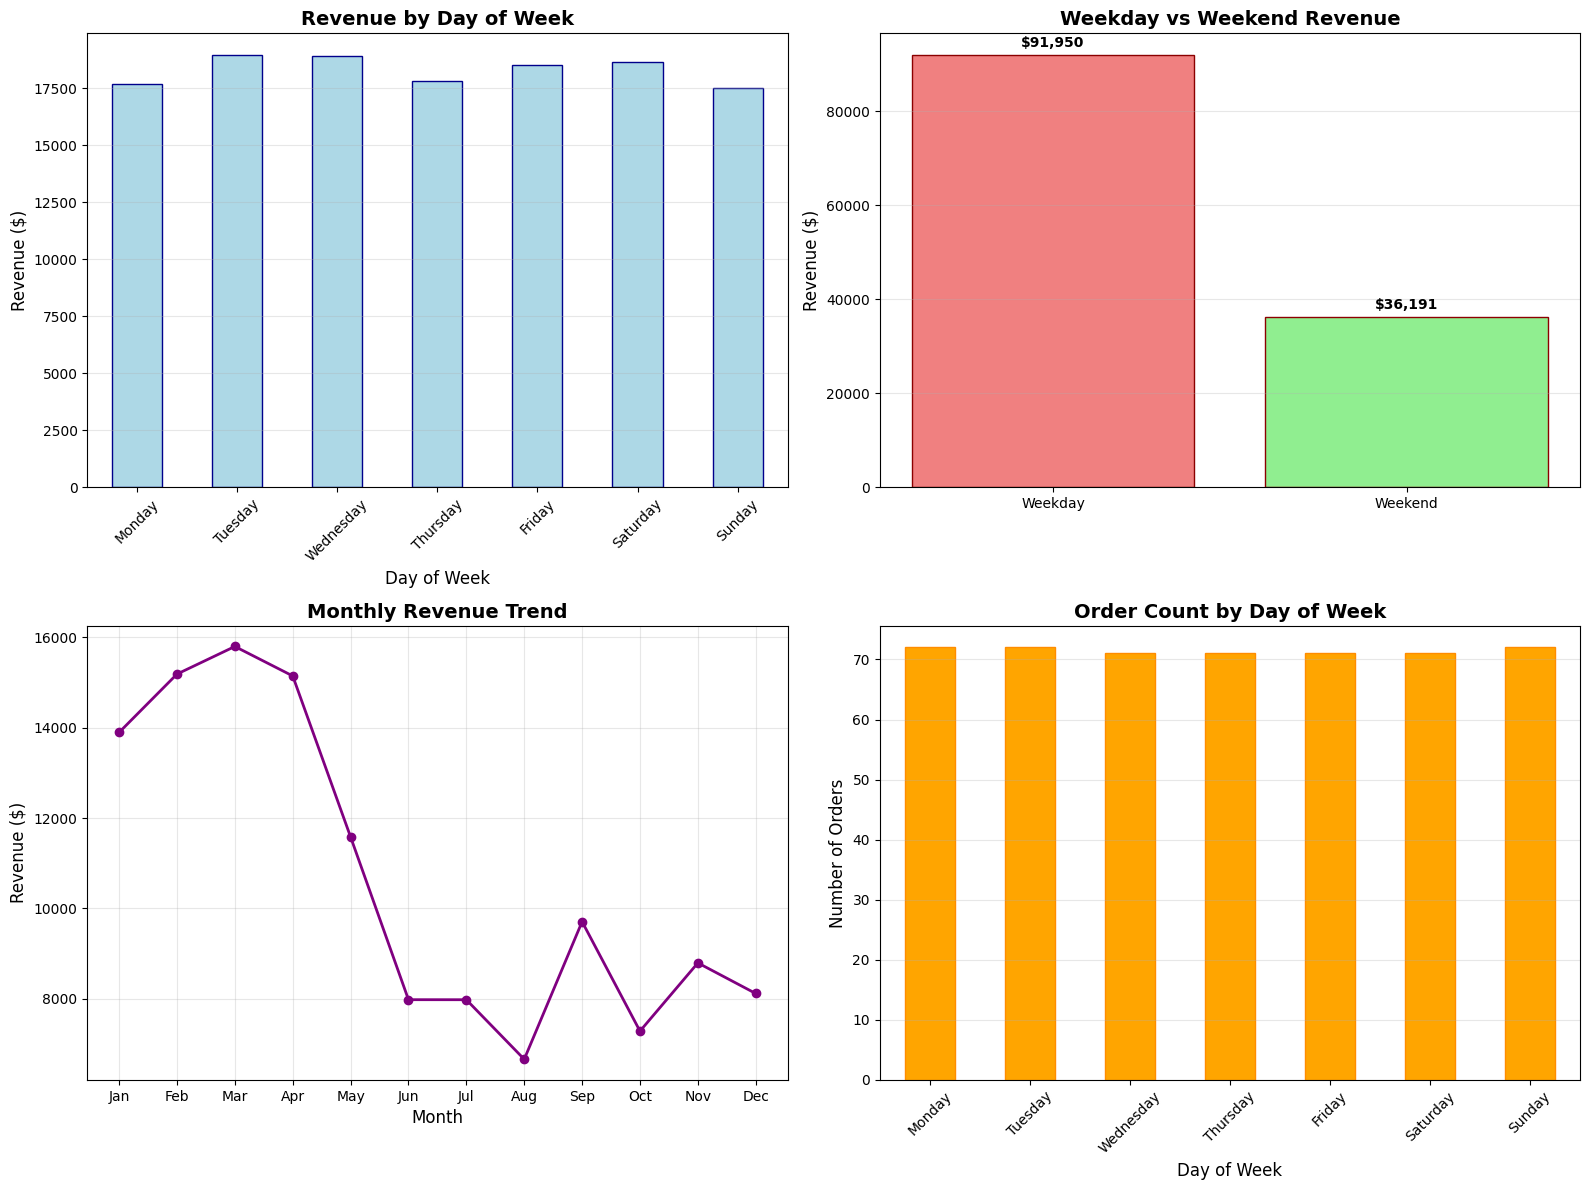


Peak Performance Analysis:
  • Best performing day: Tuesday ($18,968.41)
  • Worst performing day: Sunday ($17,530.24)
  • Best performing month: Mar ($15,795.83)
  • Worst performing month: Aug ($6,664.64)

Key Insights:
• Weekend vs Weekday revenue difference: $55,759.49
• Best day for sales: Tuesday ($18,968.41)
• Seasonal pattern: Mar is peak month
• Consider targeted marketing for low-performing days/months


In [12]:
# Your code here
# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("QUESTION 8: SEASONALITY CHECK")
print("=" * 40)

# Load and prepare data
data = pd.read_csv("ecommerce_data.csv")
data["order_date"] = pd.to_datetime(data["order_date"])
data["day_of_week"] = data["order_date"].dt.day_name()
data["weekday"] = data["order_date"].dt.weekday
data["is_weekend"] = data["weekday"].isin([5, 6])
data["month"] = data["order_date"].dt.month
data["quarter"] = data["order_date"].dt.quarter

# Analyze weekday patterns
weekday_revenue = data.groupby('day_of_week')['revenue'].sum()
weekday_orders = data.groupby('day_of_week')['order_id'].count()

# Order days of week properly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_revenue = weekday_revenue.reindex(day_order)
weekday_orders = weekday_orders.reindex(day_order)

print("Revenue by Day of Week:")
for day in day_order:
    revenue = weekday_revenue[day]
    orders = weekday_orders[day]
    avg_order = revenue / orders if orders > 0 else 0
    print(f"  {day}: ${revenue:,.2f} ({orders} orders, ${avg_order:.2f} avg)")

# Weekend vs Weekday analysis
weekend_data = data[data['is_weekend']]
weekday_data = data[~data['is_weekend']]

weekend_revenue = weekend_data['revenue'].sum()
weekday_revenue_total = weekday_data['revenue'].sum()
weekend_orders = len(weekend_data)
weekday_orders_total = len(weekday_data)

weekend_avg = weekend_revenue / weekend_orders if weekend_orders > 0 else 0
weekday_avg = weekday_revenue_total / weekday_orders_total if weekday_orders_total > 0 else 0

print(f"\nWeekend vs Weekday Comparison:")
print(f"  Weekend:")
print(f"    • Total Revenue: ${weekend_revenue:,.2f}")
print(f"    • Total Orders: {weekend_orders}")
print(f"    • Average Order Value: ${weekend_avg:.2f}")
print(f"  Weekday:")
print(f"    • Total Revenue: ${weekday_revenue_total:,.2f}")
print(f"    • Total Orders: {weekday_orders_total}")
print(f"    • Average Order Value: ${weekday_avg:.2f}")

if weekend_revenue > weekday_revenue_total:
    print("\n✅ Weekends generate MORE revenue than weekdays")
elif weekend_revenue < weekday_revenue_total:
    print("\n❌ Weekdays generate MORE revenue than weekends")
else:
    print("\n➖ Weekends and weekdays generate EQUAL revenue")

# Monthly seasonality analysis
monthly_revenue = data.groupby('month')['revenue'].sum()
monthly_orders = data.groupby('month')['order_id'].count()

print(f"\nMonthly Seasonality Analysis:")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month in monthly_revenue.index:
    month_name = month_names[month - 1]
    revenue = monthly_revenue[month]
    orders = monthly_orders[month]
    print(f"  {month_name}: ${revenue:,.2f} ({orders} orders)")

# Quarterly analysis
quarterly_revenue = data.groupby('quarter')['revenue'].sum()
quarterly_orders = data.groupby('quarter')['order_id'].count()

print(f"\nQuarterly Analysis:")
for quarter in quarterly_revenue.index:
    revenue = quarterly_revenue[quarter]
    orders = quarterly_orders[quarter]
    print(f"  Q{quarter}: ${revenue:,.2f} ({orders} orders)")

# Statistical analysis
from scipy import stats

# Test for significant differences between weekdays
weekday_revenues = []
weekday_labels = []
for day in day_order:
    day_data = data[data['day_of_week'] == day]['revenue']
    if len(day_data) > 0:
        weekday_revenues.append(day_data)
        weekday_labels.append(day)

f_stat, p_value = stats.f_oneway(*weekday_revenues)
print(f"\nStatistical Analysis:")
print(f"  ANOVA test for weekday differences:")
print(f"    • F-statistic: {f_stat:.3f}")
print(f"    • P-value: {p_value:.3f}")
if p_value < 0.05:
    print("    • Significant difference between days of week (p < 0.05)")
else:
    print("    • No significant difference between days of week (p >= 0.05)")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Revenue by day of week
weekday_revenue.plot(kind='bar', ax=ax1, color='lightblue', edgecolor='darkblue')
ax1.set_title('Revenue by Day of Week', fontsize=14, fontweight='bold')
ax1.set_ylabel('Revenue ($)', fontsize=12)
ax1.set_xlabel('Day of Week', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Weekend vs Weekday comparison
weekend_data_viz = ['Weekday', 'Weekend']
weekend_values = [weekday_revenue_total, weekend_revenue]
colors = ['lightcoral', 'lightgreen']
bars = ax2.bar(weekend_data_viz, weekend_values, color=colors, edgecolor='darkred')
ax2.set_title('Weekday vs Weekend Revenue', fontsize=14, fontweight='bold')
ax2.set_ylabel('Revenue ($)', fontsize=12)
for bar, value in zip(bars, weekend_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Monthly revenue trend
monthly_revenue.plot(kind='line', ax=ax3, marker='o', color='purple', linewidth=2)
ax3.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax3.set_ylabel('Revenue ($)', fontsize=12)
ax3.set_xlabel('Month', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(month_names)

# Orders by day of week
weekday_orders.plot(kind='bar', ax=ax4, color='orange', edgecolor='darkorange')
ax4.set_title('Order Count by Day of Week', fontsize=14, fontweight='bold')
ax4.set_ylabel('Number of Orders', fontsize=12)
ax4.set_xlabel('Day of Week', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Peak performance analysis
best_day = weekday_revenue.idxmax()
worst_day = weekday_revenue.idxmin()
best_month = monthly_revenue.idxmax()
worst_month = monthly_revenue.idxmin()

print(f"\nPeak Performance Analysis:")
print(f"  • Best performing day: {best_day} (${weekday_revenue[best_day]:,.2f})")
print(f"  • Worst performing day: {worst_day} (${weekday_revenue[worst_day]:,.2f})")
print(f"  • Best performing month: {month_names[best_month-1]} (${monthly_revenue[best_month]:,.2f})")
print(f"  • Worst performing month: {month_names[worst_month-1]} (${monthly_revenue[worst_month]:,.2f})")

print(f"\nKey Insights:")
print(f"• Weekend vs Weekday revenue difference: ${abs(weekend_revenue - weekday_revenue_total):,.2f}")
print(f"• Best day for sales: {best_day} (${weekday_revenue[best_day]:,.2f})")
print(f"• Seasonal pattern: {month_names[best_month-1]} is peak month")
print(f"• Consider targeted marketing for low-performing days/months")


### 9. Profitability (Stretch)
Assume profit margin = 20% of revenue. Estimate total profit and identify the most profitable region.

QUESTION 9: PROFITABILITY ANALYSIS
Profitability Overview:
  Total Revenue: $128,140.67
  Total Estimated Profit (20% margin): $25,628.13
  Profit Margin: 20.0%

Regional Profitability Analysis:
  South Region:
    • Total Profit: $6,967.89
    • Total Revenue: $34,839.45
    • Orders: 127
    • Profit per Order: $54.87
  North Region:
    • Total Profit: $6,870.34
    • Total Revenue: $34,351.69
    • Orders: 133
    • Profit per Order: $51.66
  East Region:
    • Total Profit: $6,244.36
    • Total Revenue: $31,221.80
    • Orders: 130
    • Profit per Order: $48.03
  West Region:
    • Total Profit: $5,545.55
    • Total Revenue: $27,727.73
    • Orders: 110
    • Profit per Order: $50.41

🏆 Most Profitable Region: South ($6,967.89)

Customer Segment Profitability:
  Student:
    • Total Profit: $10,457.06
    • Profit per Order: $50.76
    • Orders: 206
  Professional:
    • Total Profit: $9,561.41
    • Profit per Order: $51.13
    • Orders: 187
  Senior:
    • Total Profit: $5,60

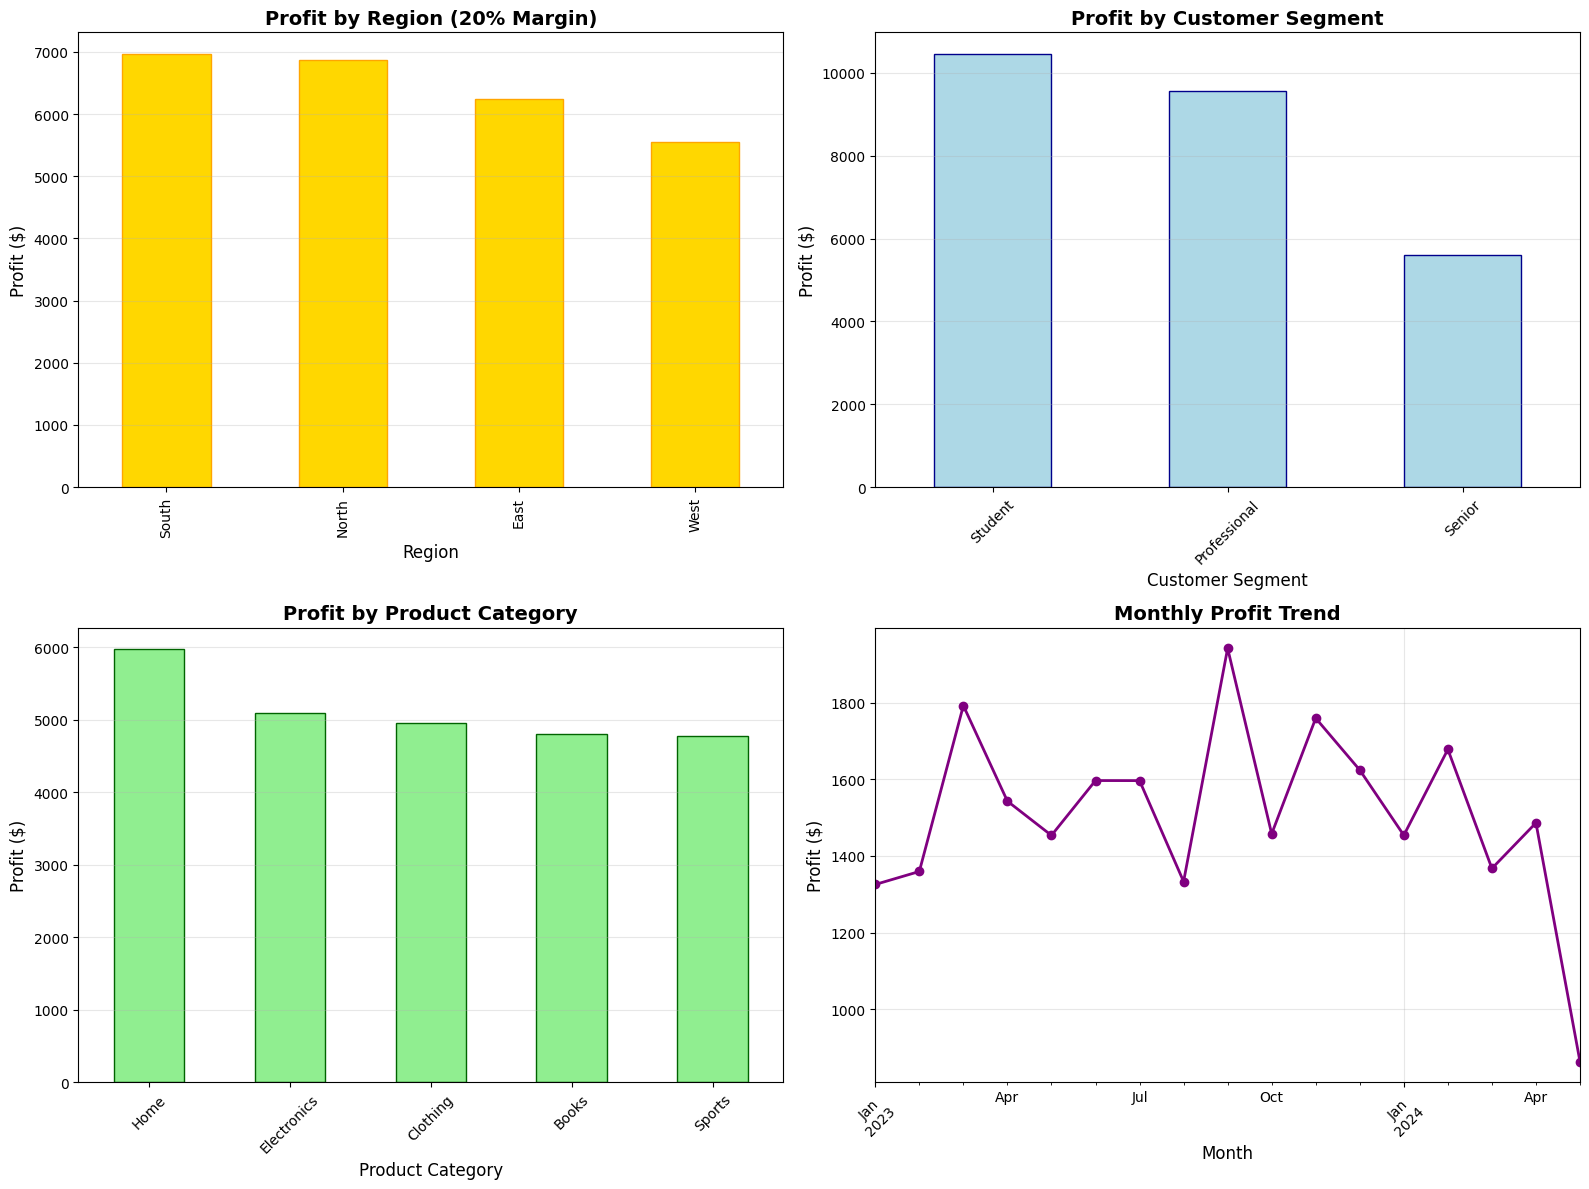


Profit Concentration Analysis:
  • Top 5 customers generate: $3,293.79 (12.9% of total profit)
  • Profit concentration: Low

Key Insights:
• Most profitable region: South ($6,967.89)
• Most profitable segment: Student
• Most profitable category: Home
• Total estimated profit: $25,628.13 (20% margin)
• Focus on high-profit regions and segments for growth


In [13]:
# Your code here
# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("QUESTION 9: PROFITABILITY ANALYSIS")
print("=" * 45)

# Load and prepare data
data = pd.read_csv("ecommerce_data.csv")

# Assume 20% profit margin
profit_margin = 0.20
data['profit'] = data['revenue'] * profit_margin

total_profit = data['profit'].sum()
total_revenue = data['revenue'].sum()

print(f"Profitability Overview:")
print(f"  Total Revenue: ${total_revenue:,.2f}")
print(f"  Total Estimated Profit (20% margin): ${total_profit:,.2f}")
print(f"  Profit Margin: {profit_margin*100}%")

# Regional profitability analysis
regional_profit = data.groupby('region')['profit'].sum().sort_values(ascending=False)
regional_revenue = data.groupby('region')['revenue'].sum()
regional_orders = data.groupby('region')['order_id'].count()

print(f"\nRegional Profitability Analysis:")
for region in regional_profit.index:
    profit = regional_profit[region]
    revenue = regional_revenue[region]
    orders = regional_orders[region]
    profit_per_order = profit / orders
    print(f"  {region} Region:")
    print(f"    • Total Profit: ${profit:,.2f}")
    print(f"    • Total Revenue: ${revenue:,.2f}")
    print(f"    • Orders: {orders}")
    print(f"    • Profit per Order: ${profit_per_order:.2f}")

most_profitable_region = regional_profit.index[0]
print(f"\n🏆 Most Profitable Region: {most_profitable_region} (${regional_profit[most_profitable_region]:,.2f})")

# Customer segment profitability
segment_profit = data.groupby('customer_segment')['profit'].sum().sort_values(ascending=False)
segment_revenue = data.groupby('customer_segment')['revenue'].sum()
segment_orders = data.groupby('customer_segment')['order_id'].count()

print(f"\nCustomer Segment Profitability:")
for segment in segment_profit.index:
    profit = segment_profit[segment]
    revenue = segment_revenue[segment]
    orders = segment_orders[segment]
    profit_per_order = profit / orders
    print(f"  {segment}:")
    print(f"    • Total Profit: ${profit:,.2f}")
    print(f"    • Profit per Order: ${profit_per_order:.2f}")
    print(f"    • Orders: {orders}")

most_profitable_segment = segment_profit.index[0]
print(f"\n🏆 Most Profitable Customer Segment: {most_profitable_segment}")

# Product category profitability
category_profit = data.groupby('product_category')['profit'].sum().sort_values(ascending=False)
category_revenue = data.groupby('product_category')['revenue'].sum()
category_orders = data.groupby('product_category')['order_id'].count()

print(f"\nProduct Category Profitability:")
for category in category_profit.index:
    profit = category_profit[category]
    revenue = category_revenue[category]
    orders = category_orders[category]
    profit_per_order = profit / orders
    print(f"  {category}:")
    print(f"    • Total Profit: ${profit:,.2f}")
    print(f"    • Profit per Order: ${profit_per_order:.2f}")
    print(f"    • Orders: {orders}")

most_profitable_category = category_profit.index[0]
print(f"\n🏆 Most Profitable Product Category: {most_profitable_category}")

# Top customer profitability
customer_profit = data.groupby('customer_id')['profit'].sum().sort_values(ascending=False).head(5)
customer_revenue = data.groupby('customer_id')['revenue'].sum()
customer_orders = data.groupby('customer_id')['order_id'].count()

print(f"\nTop 5 Most Profitable Customers:")
for i, (customer_id, profit) in enumerate(customer_profit.items(), 1):
    revenue = customer_revenue[customer_id]
    orders = customer_orders[customer_id]
    print(f"  {i}. Customer {customer_id}: ${profit:,.2f} profit (${revenue:,.2f} revenue, {orders} orders)")

# Monthly profitability trend
data['month'] = pd.to_datetime(data['order_date']).dt.to_period('M')
monthly_profit = data.groupby('month')['profit'].sum()
monthly_revenue = data.groupby('month')['revenue'].sum()

print(f"\nMonthly Profitability Trend:")
for month in monthly_profit.index:
    profit = monthly_profit[month]
    revenue = monthly_revenue[month]
    margin = (profit / revenue * 100) if revenue > 0 else 0
    print(f"  {month}: ${profit:,.2f} profit (${revenue:,.2f} revenue, {margin:.1f}% margin)")

# Profitability efficiency metrics
regional_efficiency = regional_profit / regional_orders  # Profit per order by region
segment_efficiency = segment_profit / segment_orders    # Profit per order by segment
category_efficiency = category_profit / category_orders # Profit per order by category

print(f"\nProfitability Efficiency (Profit per Order):")
print(f"  By Region:")
for region, efficiency in regional_efficiency.sort_values(ascending=False).items():
    print(f"    {region}: ${efficiency:.2f}")
print(f"  By Customer Segment:")
for segment, efficiency in segment_efficiency.sort_values(ascending=False).items():
    print(f"    {segment}: ${efficiency:.2f}")
print(f"  By Product Category:")
for category, efficiency in category_efficiency.sort_values(ascending=False).items():
    print(f"    {category}: ${efficiency:.2f}")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Regional profitability
regional_profit.plot(kind='bar', ax=ax1, color='gold', edgecolor='orange')
ax1.set_title('Profit by Region (20% Margin)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Profit ($)', fontsize=12)
ax1.set_xlabel('Region', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Customer segment profitability
segment_profit.plot(kind='bar', ax=ax2, color='lightblue', edgecolor='darkblue')
ax2.set_title('Profit by Customer Segment', fontsize=14, fontweight='bold')
ax2.set_ylabel('Profit ($)', fontsize=12)
ax2.set_xlabel('Customer Segment', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Product category profitability
category_profit.plot(kind='bar', ax=ax3, color='lightgreen', edgecolor='darkgreen')
ax3.set_title('Profit by Product Category', fontsize=14, fontweight='bold')
ax3.set_ylabel('Profit ($)', fontsize=12)
ax3.set_xlabel('Product Category', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Monthly profit trend
monthly_profit.plot(kind='line', ax=ax4, marker='o', color='purple', linewidth=2)
ax4.set_title('Monthly Profit Trend', fontsize=14, fontweight='bold')
ax4.set_ylabel('Profit ($)', fontsize=12)
ax4.set_xlabel('Month', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Profit concentration analysis
top_5_customers_profit = customer_profit.head(5).sum()
total_profit_percentage = (top_5_customers_profit / total_profit * 100)

print(f"\nProfit Concentration Analysis:")
print(f"  • Top 5 customers generate: ${top_5_customers_profit:,.2f} ({total_profit_percentage:.1f}% of total profit)")
print(f"  • Profit concentration: {'High' if total_profit_percentage > 30 else 'Medium' if total_profit_percentage > 15 else 'Low'}")

print(f"\nKey Insights:")
print(f"• Most profitable region: {most_profitable_region} (${regional_profit[most_profitable_region]:,.2f})")
print(f"• Most profitable segment: {most_profitable_segment}")
print(f"• Most profitable category: {most_profitable_category}")
print(f"• Total estimated profit: ${total_profit:,.2f} (20% margin)")
print(f"• Focus on high-profit regions and segments for growth")

### 10. Business Recommendation
Based on your findings, recommend one strategy (e.g., focus on certain customer segments, increase discounts, promote specific regions/products).

**Your recommendation here:**

Write your analysis and recommendation based on the insights you discovered from the data.

Based on the data by centering efforts on senior customers in the South region, particularly within the Home product category and emphasizing debit card payment incentives, the business can maximize both profitability and customer satisfaction. This focused approach not only leverages the company’s strongest performance indicators but also establishes a scalable framework for long-term growth and customer loyalty.

---

## Submission Requirements

1. **Complete code** for all 10 questions
2. **Clear visualizations** where appropriate  
3. **Brief interpretation** of each result
4. **Final business recommendation** with supporting data

Remember: Focus on what the numbers tell us about the business, not just the calculations themselves.